# Feature Engineering Progression

End-to-end evidence of the incremental 4-baseline → 9-feature chain for
unsupervised BIM classification. Each stage adds one feature on top of the
previous set. Metrics at k ∈ {2, 4, 8, 16, 24, 32} over 10 seeds against 19
merged IFC types. Headline k = **32**.

Sections:
1. Overall progression (pivot, headline table, 4-metric overlay)
2. Stage-by-stage gain (ΔPurity per stage, feature correlations, RF importance)
3. Per-stage evidence figures
4. Per-type journey
5. Final cluster composition at k=32
6. Data-driven takeaways


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, 'feature_engineering')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from _common import (
    RESULTS_ROOT, FEATURE_ORDER, K_VALUES, K_MAIN,
    BASELINE, ALL_ENGINEERED, build_X, cumulative_bounded_up_to,
    load_data, kmeans_labels, per_type_purity, compute_purity,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

progression = pd.read_csv(RESULTS_ROOT / 'progression_summary.csv')
config_order = [name for _, name, _ in FEATURE_ORDER]
progression['config'] = pd.Categorical(progression['config'], categories=config_order, ordered=True)
progression = progression.sort_values(['config', 'k']).reset_index(drop=True)

df, ifc_merged = load_data()
n_types = len(set(ifc_merged))
print(f'{len(df)} objects · {n_types} merged types · {len(FEATURE_ORDER)} stages · '
      f'k-grid = {K_VALUES} · headline k = {K_MAIN}')

1700 objects · 17 merged types · 5 stages · k-grid = [2, 4, 8, 16, 24, 32] · headline k = 32


## 1. Overall progression

Pivot — rows = config, cols = k, cells = mean purity across 10 seeds:

In [2]:
progression.pivot(index='config', columns='k', values='purity_mean').round(3)

k,2,4,8,16,24,32
config,,,,,,
"Baseline (4, log)",0.213,0.280,0.349,0.429,0.473,0.507
+ Orientation (6),0.179,0.261,0.398,0.461,0.527,0.571
+ CS Ratio (7),0.202,0.278,0.407,0.520,0.611,0.650
+ Normal Entropy (8),0.224,0.274,0.410,0.540,0.642,0.679
+ Horiz Frac (9),0.226,0.307,0.418,0.569,0.662,0.704


Headline table at k = K_MAIN, with ΔPurity vs previous stage:

In [3]:
head = progression[progression.k == K_MAIN].copy()
head = head[['config', 'purity_mean', 'purity_std',
             'silhouette_mean', 'davies_bouldin_mean', 'calinski_harabasz_mean']]
head.columns = ['Config', 'Purity', 'σ', 'Silhouette', 'DB (↓)', 'CH (↑)']
head.insert(2, 'ΔPurity', head['Purity'].diff().fillna(0))
head.reset_index(drop=True).round(3)

,Config,Purity,ΔPurity,σ,Silhouette,DB (↓),CH (↑)
0,"Baseline (4, log)",0.507,0.000,0.012,0.322,1.001,872.031
1,+ Orientation (6),0.571,0.065,0.019,0.331,1.057,536.034
2,+ CS Ratio (7),0.650,0.079,0.015,0.321,1.127,386.624
3,+ Normal Entropy (8),0.679,0.028,0.011,0.317,1.181,334.130
4,+ Horiz Frac (9),0.704,0.025,0.010,0.314,1.216,320.066


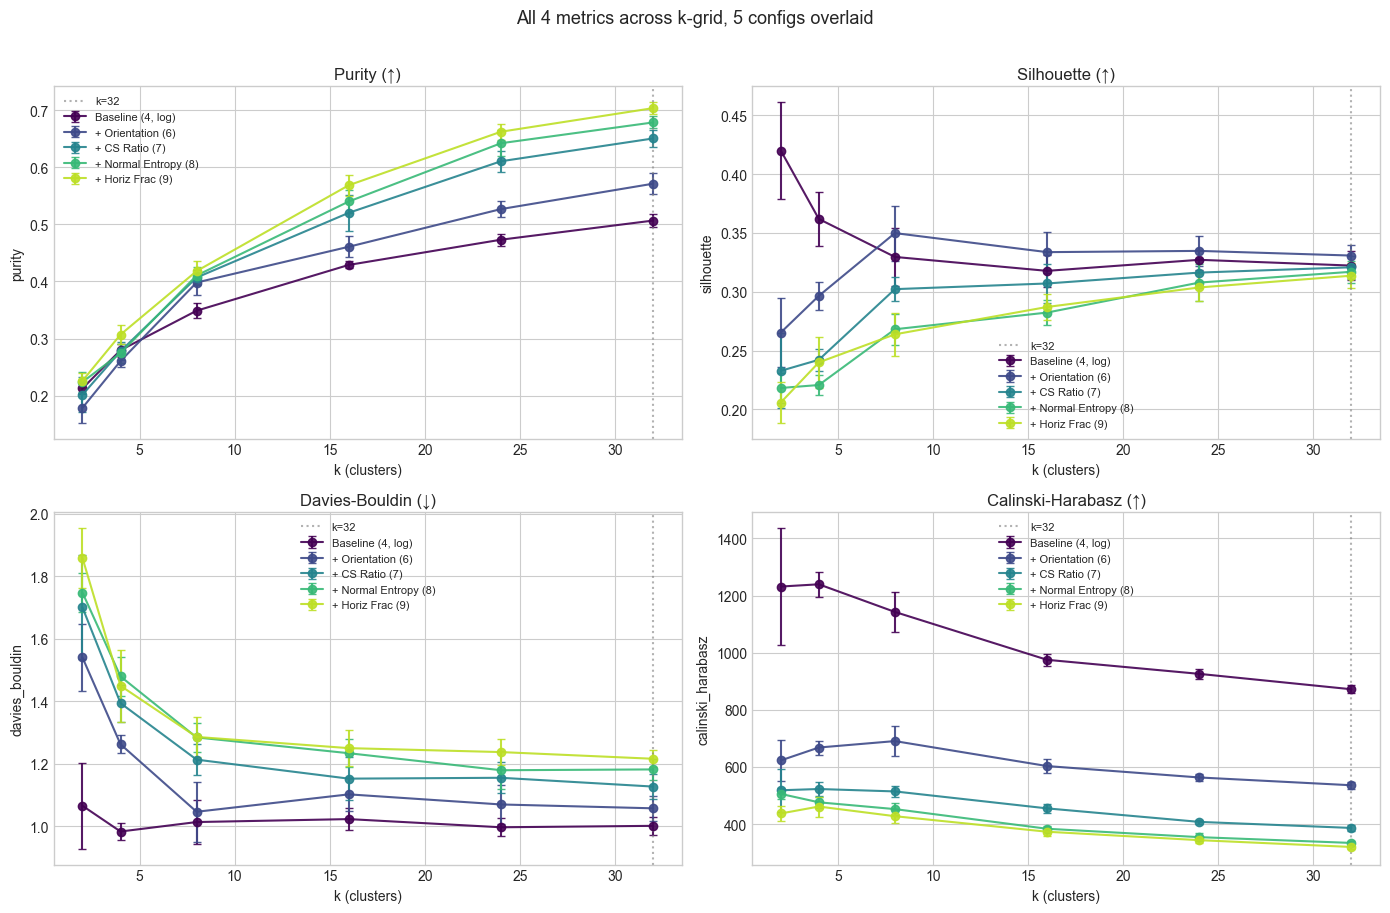

In [4]:
# 4-metric overlay across the full k-grid
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [('purity', 'Purity (↑)'),
           ('silhouette', 'Silhouette (↑)'),
           ('davies_bouldin', 'Davies-Bouldin (↓)'),
           ('calinski_harabasz', 'Calinski-Harabasz (↑)')]
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(config_order)))

for ax, (metric, title) in zip(axes.ravel(), metrics):
    for name, color in zip(config_order, cmap):
        d = progression[progression['config'] == name]
        ax.errorbar(d['k'], d[f'{metric}_mean'], yerr=d[f'{metric}_std'],
                    marker='o', capsize=3, label=name, color=color, alpha=0.9)
    ax.set_xlabel('k (clusters)'); ax.set_ylabel(metric); ax.set_title(title, fontsize=12)
    ax.axvline(K_MAIN, color='grey', linestyle=':', alpha=0.6, label=f'k={K_MAIN}')
    ax.legend(fontsize=8, loc='best')
fig.suptitle(f'All 4 metrics across k-grid, {len(config_order)} configs overlaid',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

**Pattern**: purity climbs monotonically with every feature added; silhouette,
Davies-Bouldin, and Calinski-Harabasz all drift worse because added dimensions
dilute Euclidean compactness. Purity is the supervised target; the others are
diagnostic geometry metrics.

## 2. Stage-by-stage gain

Three complementary views of what each feature contributes:

- **ΔPurity bar chart** — marginal cluster-quality gain per stage
- **Feature correlation heatmap** — are the engineered features redundant?
- **RF importance** — supervised view: how much does each feature drive a
  Random Forest that predicts merged IfcType from the cumulative feature set?

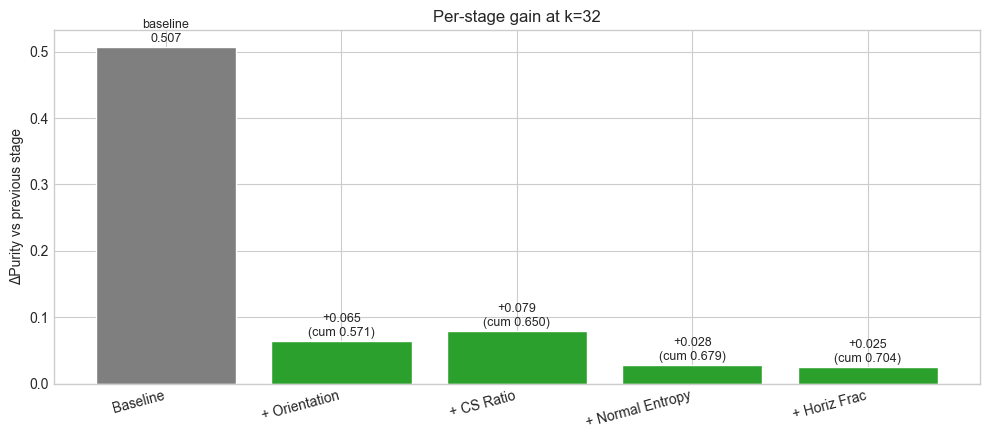

In [5]:
# ΔPurity per stage at headline k — which feature moved the needle
at_k = progression[progression.k == K_MAIN].set_index('config').reindex(config_order)
deltas = at_k['purity_mean'].diff().fillna(at_k['purity_mean'].iloc[0])

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['tab:gray'] + ['tab:green' if d > 0 else 'tab:red' for d in deltas[1:]]
ax.bar(range(len(deltas)), deltas, color=colors, edgecolor='white')
ax.axhline(0, color='k', linewidth=0.5)
for i, (name, d, p) in enumerate(zip(deltas.index, deltas, at_k['purity_mean'])):
    label = f'{d:+.3f}\n(cum {p:.3f})' if i > 0 else f'baseline\n{p:.3f}'
    ax.text(i, d + (0.003 if d >= 0 else -0.003), label,
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
ax.set_xticks(range(len(deltas)))
ax.set_xticklabels([c.split('(')[0].strip() for c in deltas.index], rotation=15, ha='right')
ax.set_ylabel('ΔPurity vs previous stage')
ax.set_title(f'Per-stage gain at k={K_MAIN}', fontsize=12)
plt.tight_layout(); plt.show()

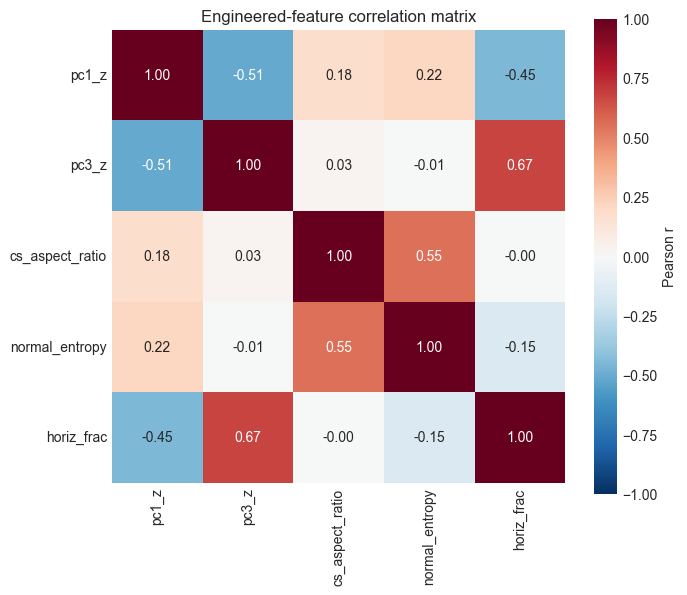

Max |r| across engineered pairs: 0.67
(low max = each feature carries mostly-independent signal)


In [6]:
# Engineered-feature correlation
eng_only = df[ALL_ENGINEERED]
corr = eng_only.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'label': 'Pearson r'})
ax.set_title('Engineered-feature correlation matrix', fontsize=12)
plt.tight_layout(); plt.show()

off_diag = corr.where(~np.eye(len(corr), dtype=bool)).abs()
print(f'Max |r| across engineered pairs: {off_diag.max().max():.2f}')
print('(low max = each feature carries mostly-independent signal)')

### Random Forest feature importance

For each stage, fit a RandomForestClassifier on the cumulative feature set at
that stage → merged IfcType. Measures how much each feature actually drives
classification when the label is known (upper bound on what clustering could
exploit).

In [7]:
# Per-stage RF importances on the cumulative feature set at that stage.
# Each stage: cumulative features = log(baseline) + bounded engineered so far.
log_baseline_names = [f'log({c})' for c in BASELINE]

def feat_names_at(stage_id):
    return log_baseline_names + cumulative_bounded_up_to(stage_id)

rf_rows = []
new_feat_tracker = {}  # feature -> which stage it was added in (display name)
for stage_id, name, feats in FEATURE_ORDER:
    for f in feats:
        new_feat_tracker[f] = name
for f in log_baseline_names:
    new_feat_tracker[f] = 'Baseline (4, log)'

rf_imp_per_stage = {}
for stage_id, name, _ in FEATURE_ORDER:
    cols = cumulative_bounded_up_to(stage_id)
    X = build_X(df, BASELINE, cols)
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1,
                                class_weight='balanced')
    rf.fit(X, ifc_merged)
    imps = dict(zip(feat_names_at(stage_id), rf.feature_importances_))
    rf_imp_per_stage[name] = imps
    oob_acc = rf.score(X, ifc_merged)  # training-set acc for sanity
    rf_rows.append({'stage': name, 'n_features': len(imps), 'rf_train_acc': oob_acc})

rf_summary = pd.DataFrame(rf_rows)
print('RF training accuracy (upper bound on how separable types are at each stage):')
print(rf_summary.round(3).to_string(index=False))

RF training accuracy (upper bound on how separable types are at each stage):
               stage  n_features  rf_train_acc
   Baseline (4, log)           4         0.996
   + Orientation (6)           6         0.998
      + CS Ratio (7)           7         0.999
+ Normal Entropy (8)           8         0.999
    + Horiz Frac (9)           9         0.999


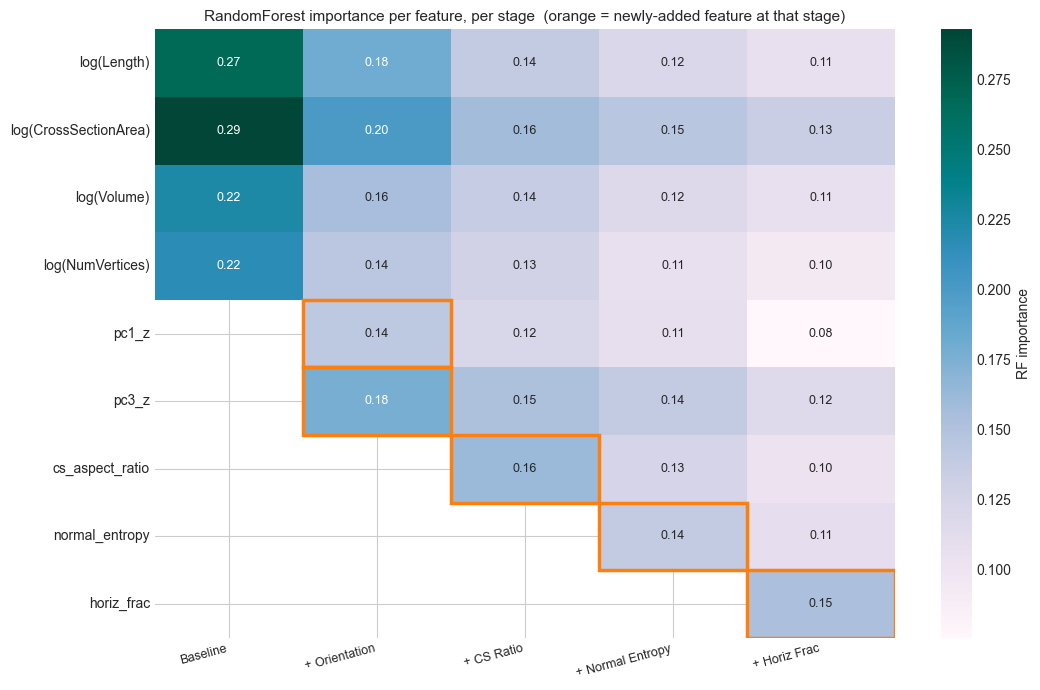

In [8]:
# Single stacked view: rows=features (all 9), cols=stages, cells=RF importance
# A feature only exists from the stage it was added onward; earlier stages → NaN (gray).
all_features = log_baseline_names + ALL_ENGINEERED
imp_matrix = pd.DataFrame(index=all_features, columns=config_order, dtype=float)
for stage_name, imps in rf_imp_per_stage.items():
    for f, v in imps.items():
        imp_matrix.loc[f, stage_name] = v

# Order features by "stage added"
order = log_baseline_names + [f for _, _, feats in FEATURE_ORDER for f in feats]
imp_matrix = imp_matrix.reindex(order)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(imp_matrix.astype(float), annot=True, fmt='.2f', cmap='PuBuGn',
            cbar_kws={'label': 'RF importance'}, ax=ax,
            mask=imp_matrix.isna(), annot_kws={'size': 9})
# Highlight the newly-added feature at each stage
for stage_idx, (_stage_id, stage_name, feats) in enumerate(FEATURE_ORDER):
    for f in feats:
        feat_idx = order.index(f)
        ax.add_patch(plt.Rectangle((stage_idx, feat_idx), 1, 1,
                                    fill=False, edgecolor='tab:orange', lw=2.5))
ax.set_xticklabels([c.split('(')[0].strip() for c in imp_matrix.columns],
                    rotation=15, ha='right', fontsize=9)
ax.set_title('RandomForest importance per feature, per stage  '
             '(orange = newly-added feature at that stage)', fontsize=11)
plt.tight_layout(); plt.show()

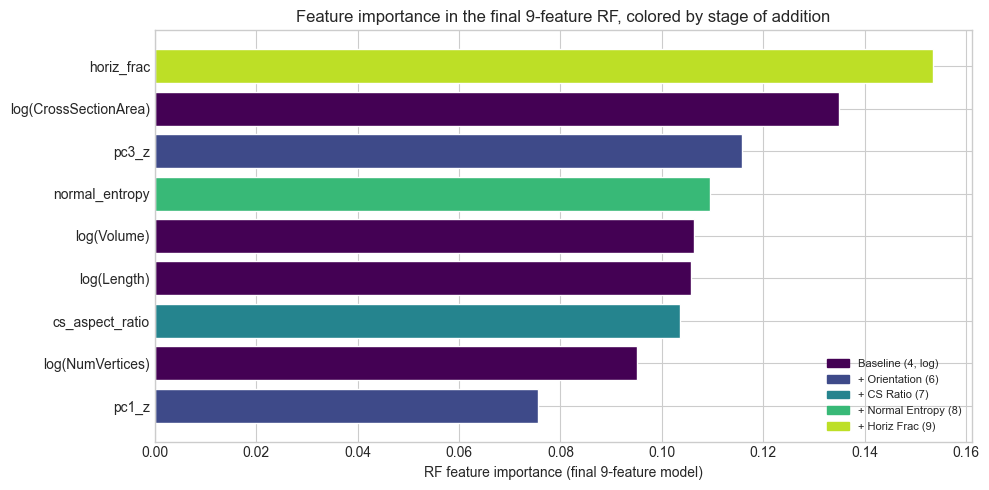


Ranked importance (final model):
  1. horiz_frac           0.153   (added in: + Horiz Frac (9))
  2. log(CrossSectionArea) 0.135   (added in: Baseline (4, log))
  3. pc3_z                0.116   (added in: + Orientation (6))
  4. normal_entropy       0.110   (added in: + Normal Entropy (8))
  5. log(Volume)          0.106   (added in: Baseline (4, log))
  6. log(Length)          0.106   (added in: Baseline (4, log))
  7. cs_aspect_ratio      0.104   (added in: + CS Ratio (7))
  8. log(NumVertices)     0.095   (added in: Baseline (4, log))
  9. pc1_z                0.076   (added in: + Orientation (6))


In [9]:
# Final-stage importance bar chart: one bar per feature, sorted by importance,
# colored by the stage it was added in.
final_imps = pd.Series(rf_imp_per_stage[config_order[-1]]).sort_values(ascending=True)
stage_colors = dict(zip(config_order, plt.cm.viridis(np.linspace(0, 0.9, len(config_order)))))
bar_colors = [stage_colors[new_feat_tracker[f]] for f in final_imps.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(final_imps.index, final_imps.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('RF feature importance (final 9-feature model)')
ax.set_title('Feature importance in the final 9-feature RF, colored by stage of addition',
             fontsize=12)
# Legend
from matplotlib.patches import Patch
legend = [Patch(color=stage_colors[s], label=s) for s in config_order]
ax.legend(handles=legend, loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

print('\nRanked importance (final model):')
for rank, (f, v) in enumerate(final_imps.sort_values(ascending=False).items(), 1):
    print(f'  {rank}. {f:<20} {v:.3f}   (added in: {new_feat_tracker[f]})')

## 3. Per-stage evidence figures

One block per stage, loading saved PNGs at native resolution. Each block:
pre-state failure, new-feature distribution by type, ANOVA separation
potential, k-sweep prev-vs-new, per-type Δ at k=32.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  + Orientation (6)   (01_orientation)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ Pre-state failure


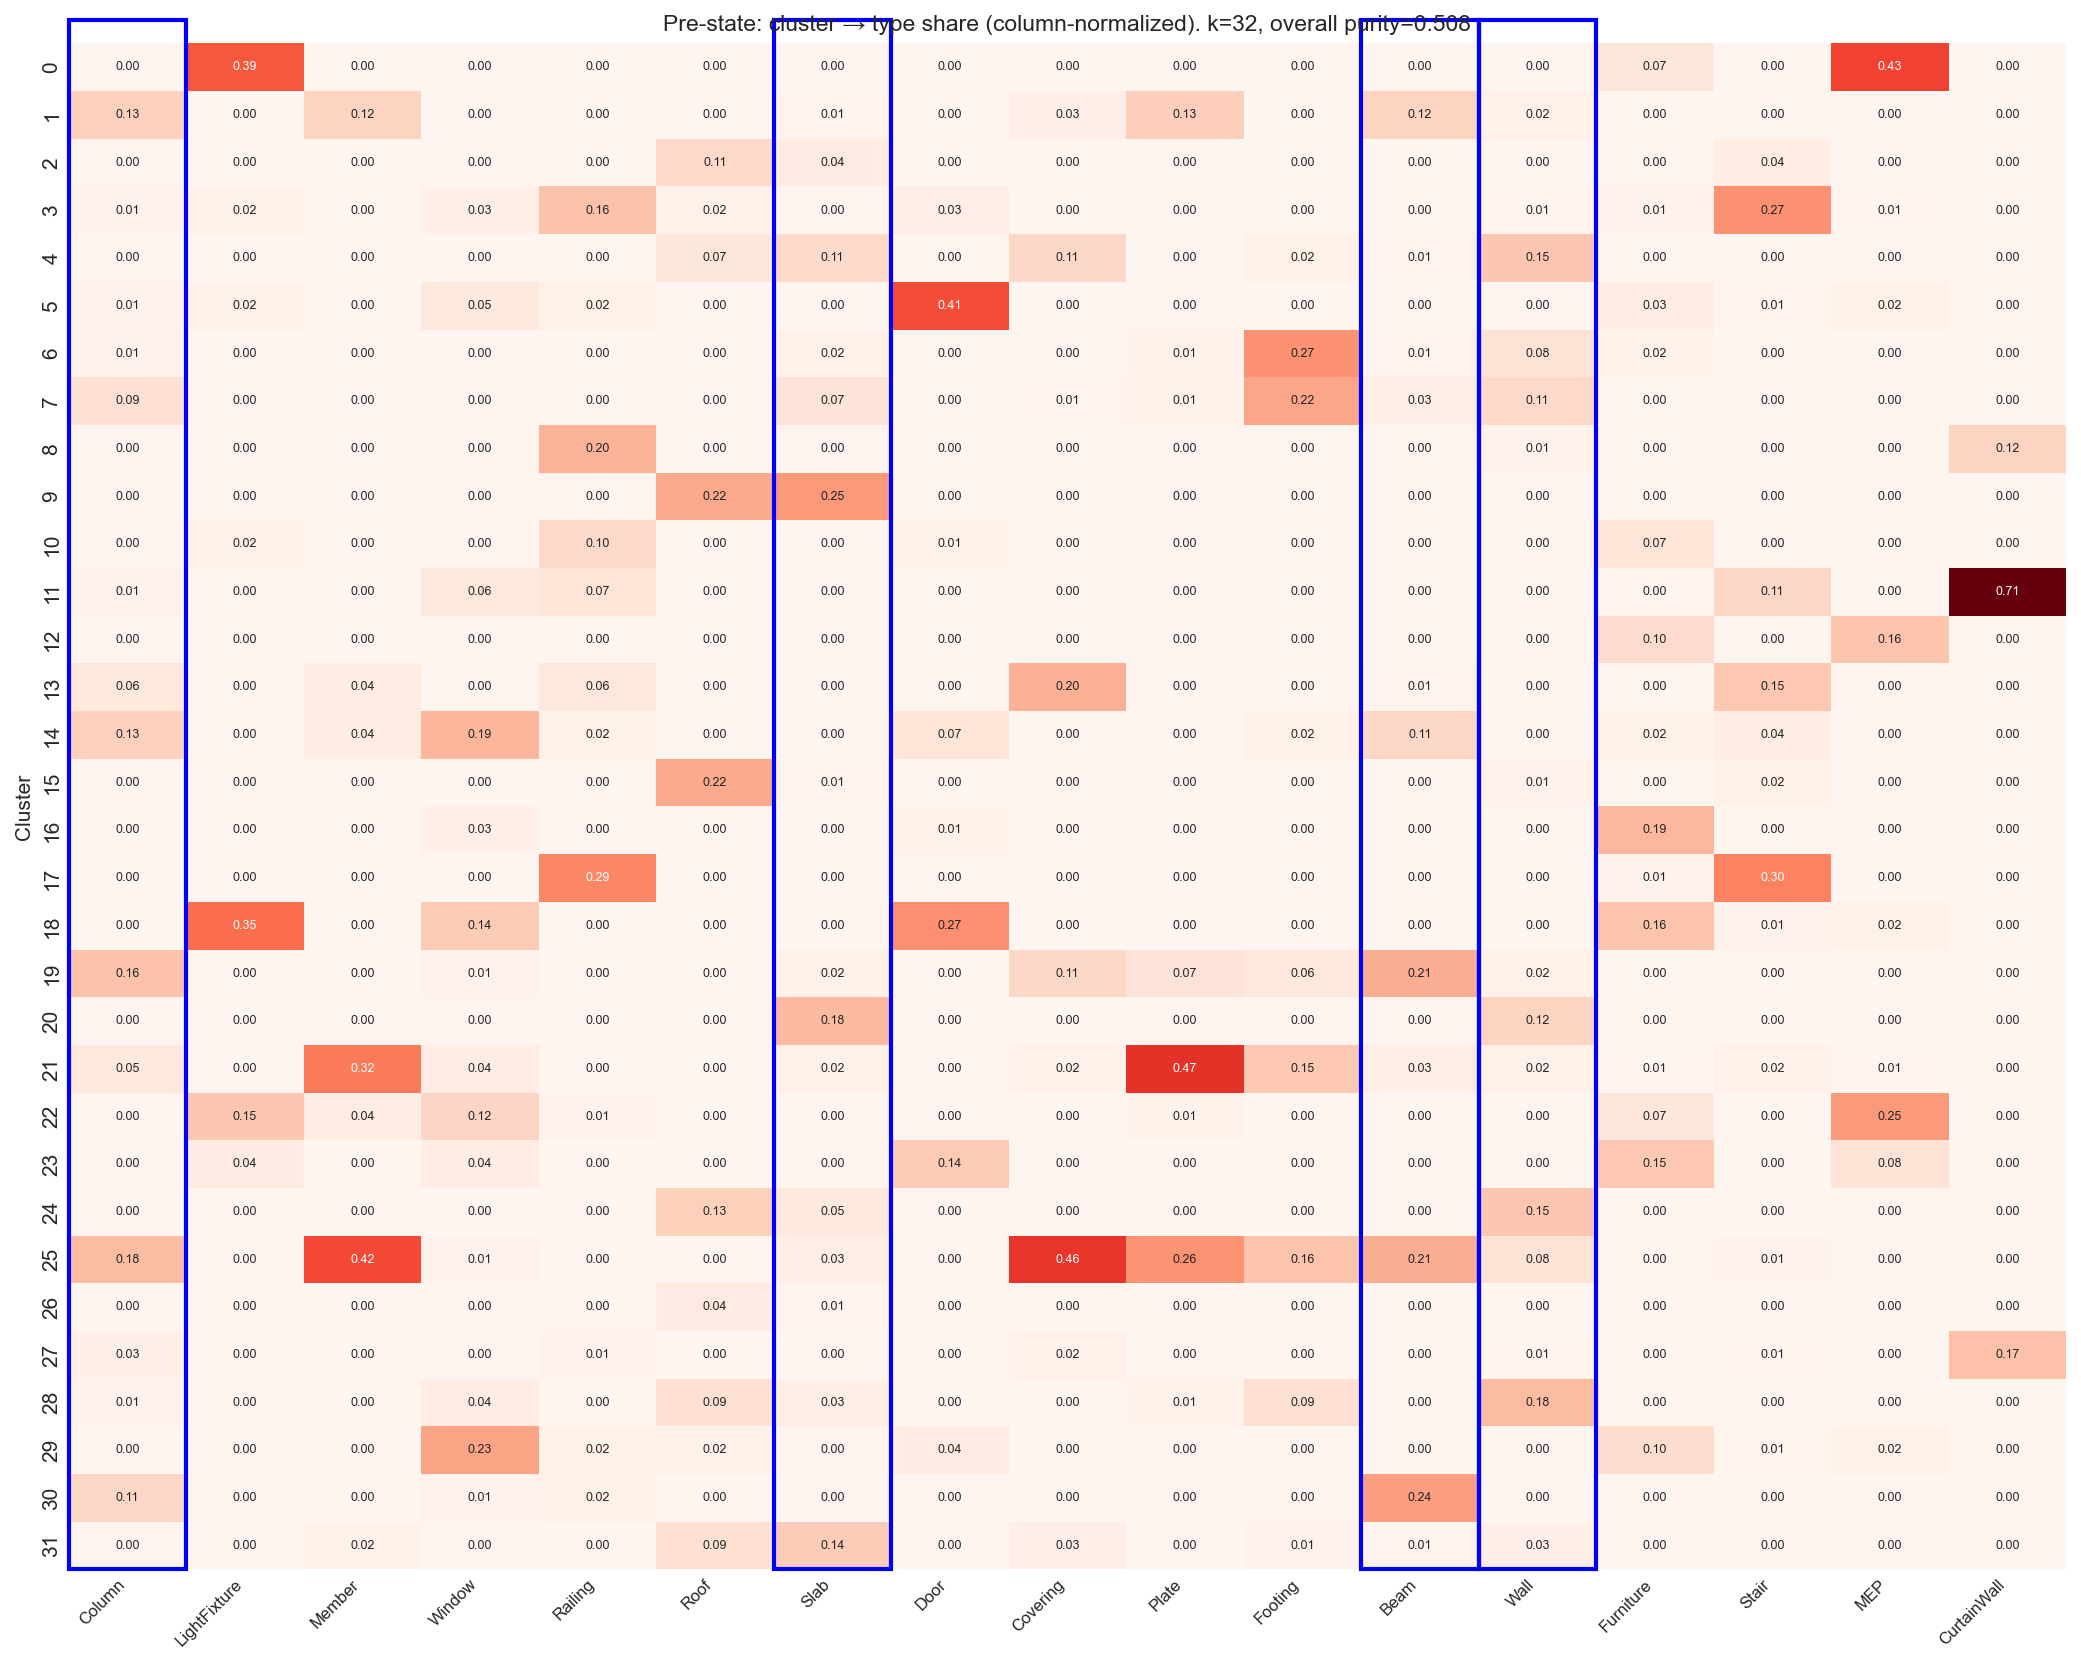


▸ pc1_z by merged type


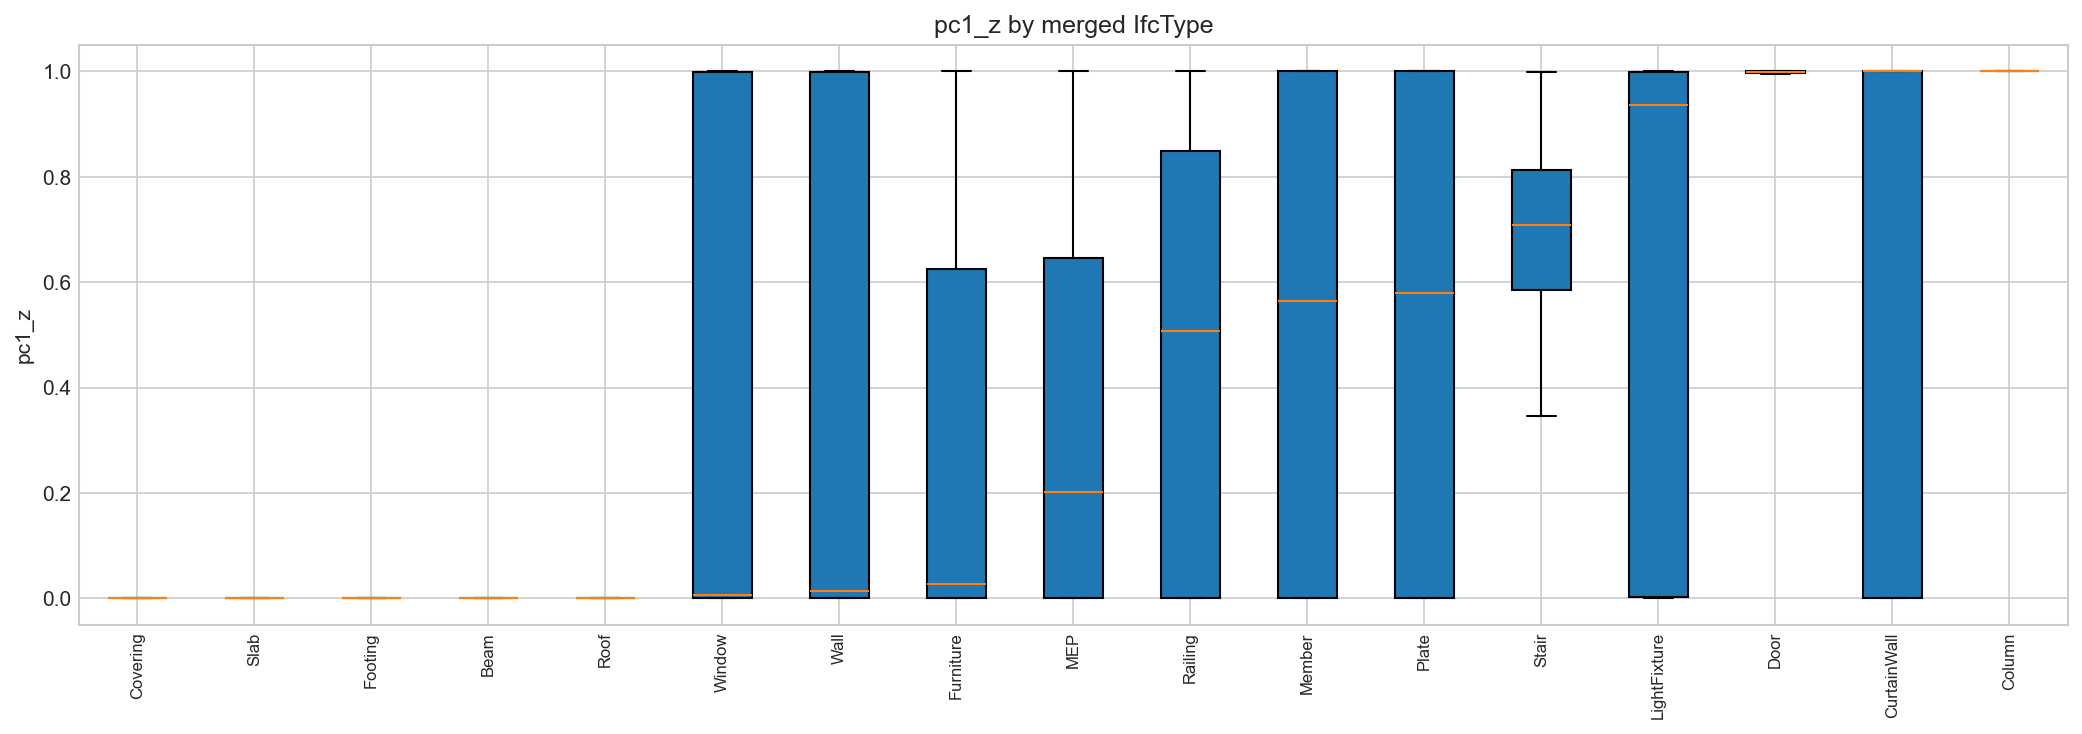


▸ pc3_z by merged type


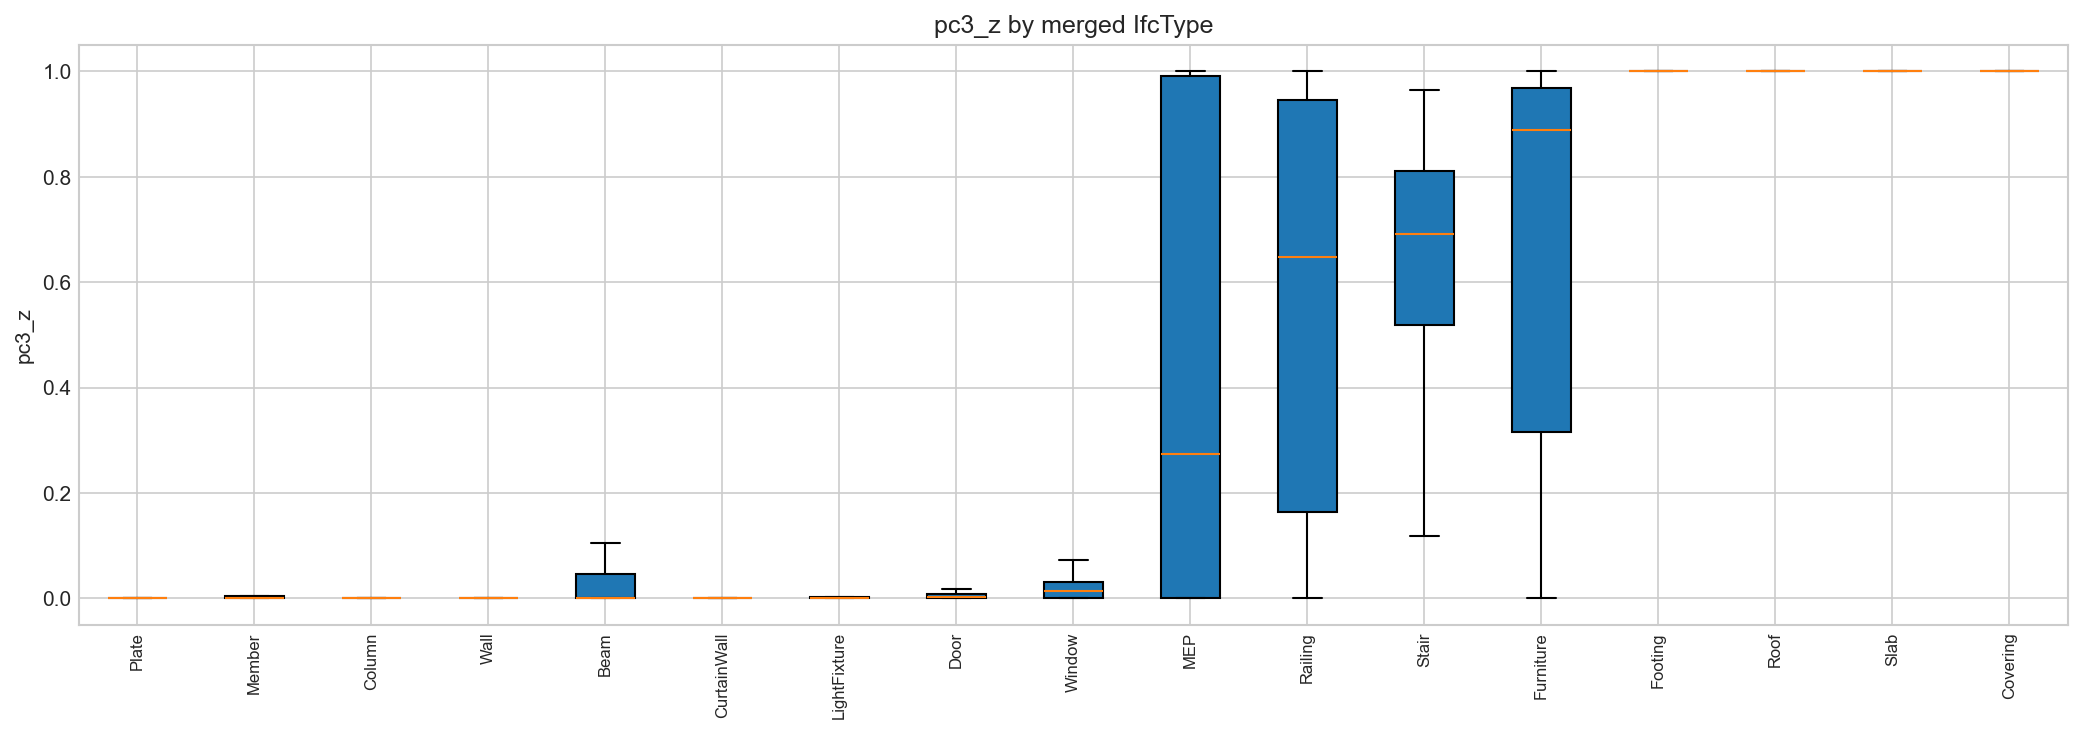


▸ Separation potential (ANOVA F)


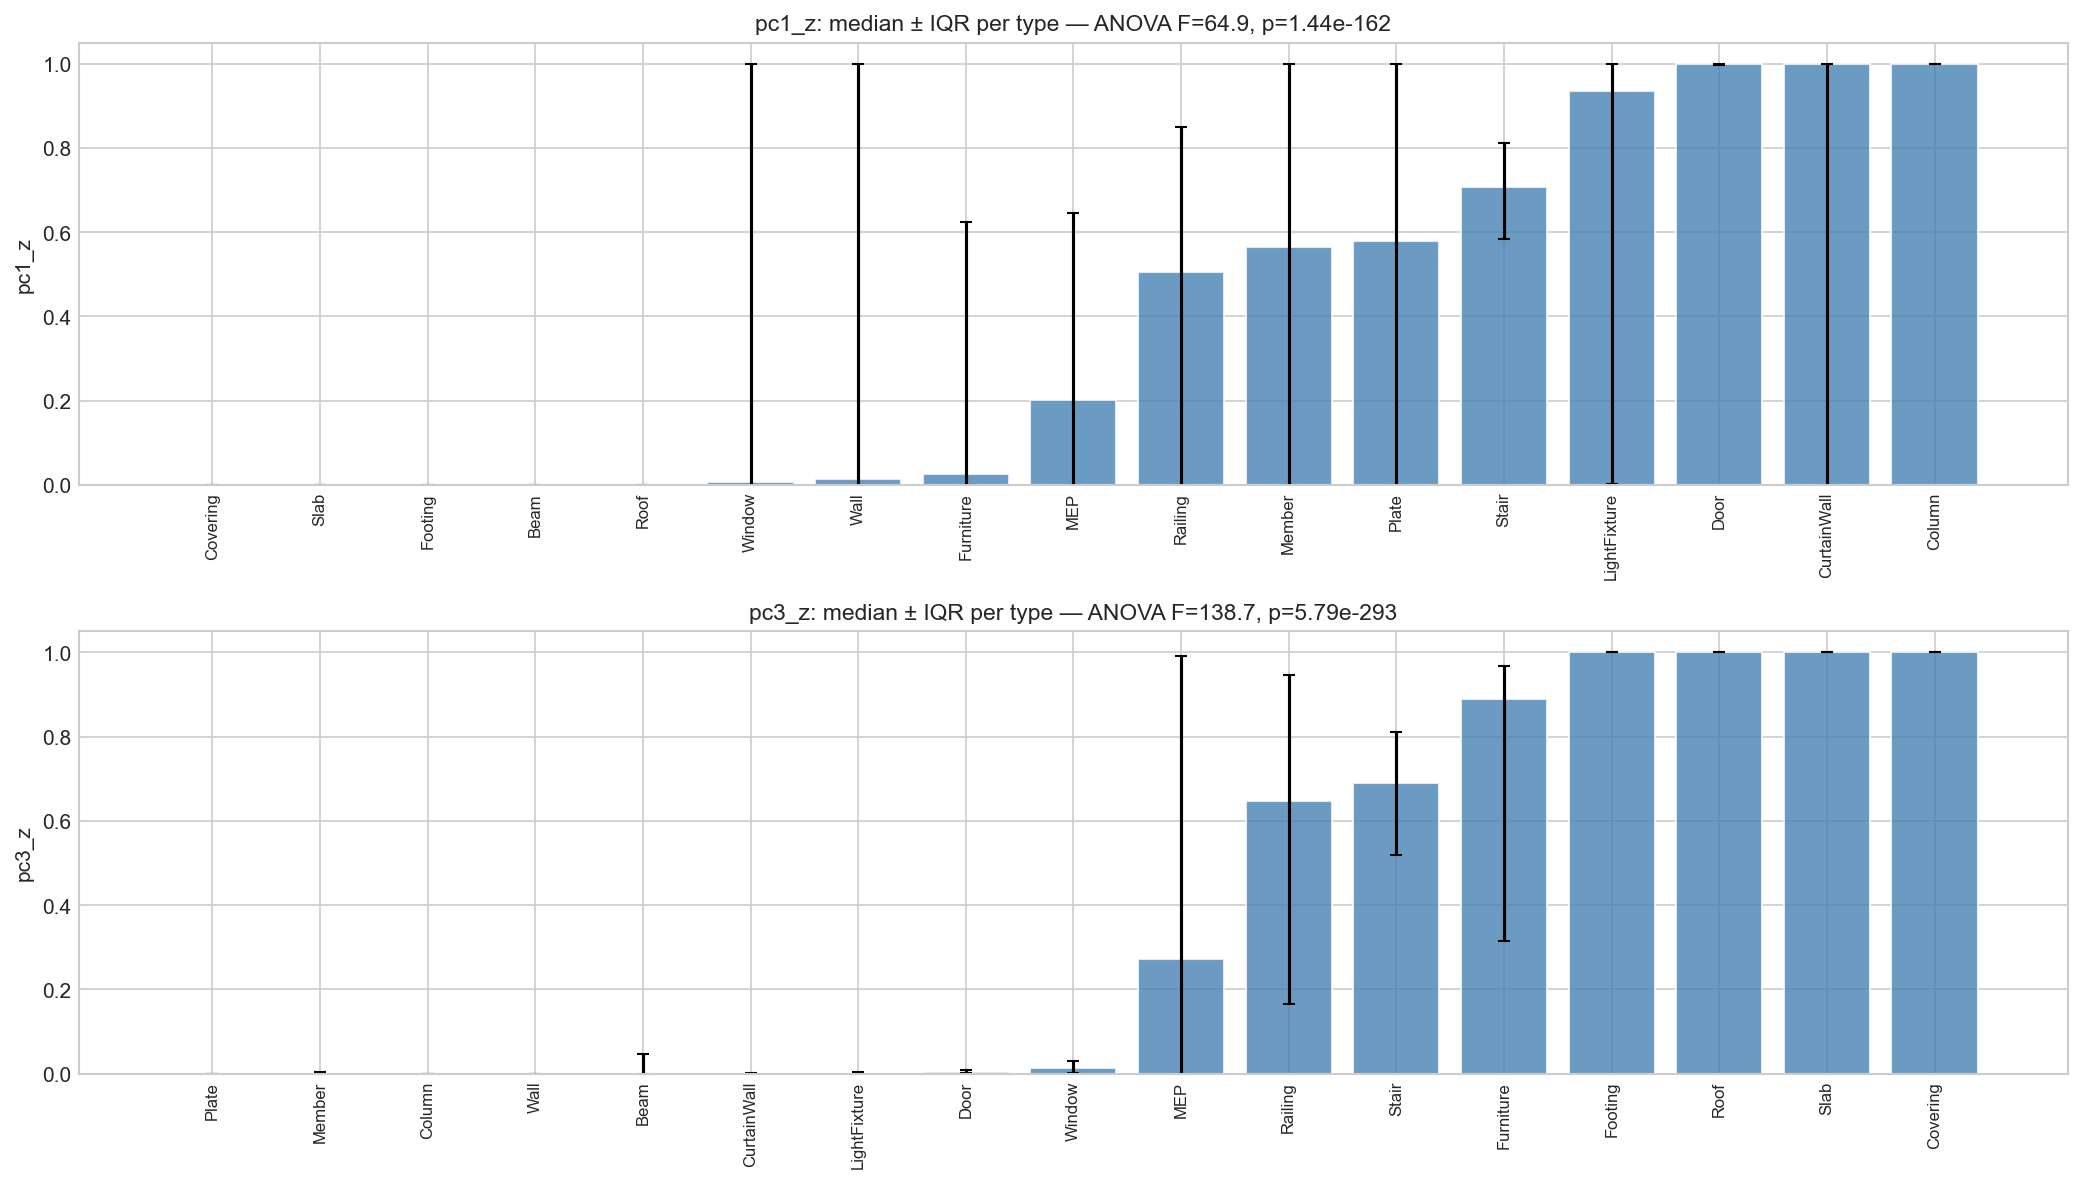


▸ k-sweep prev vs new


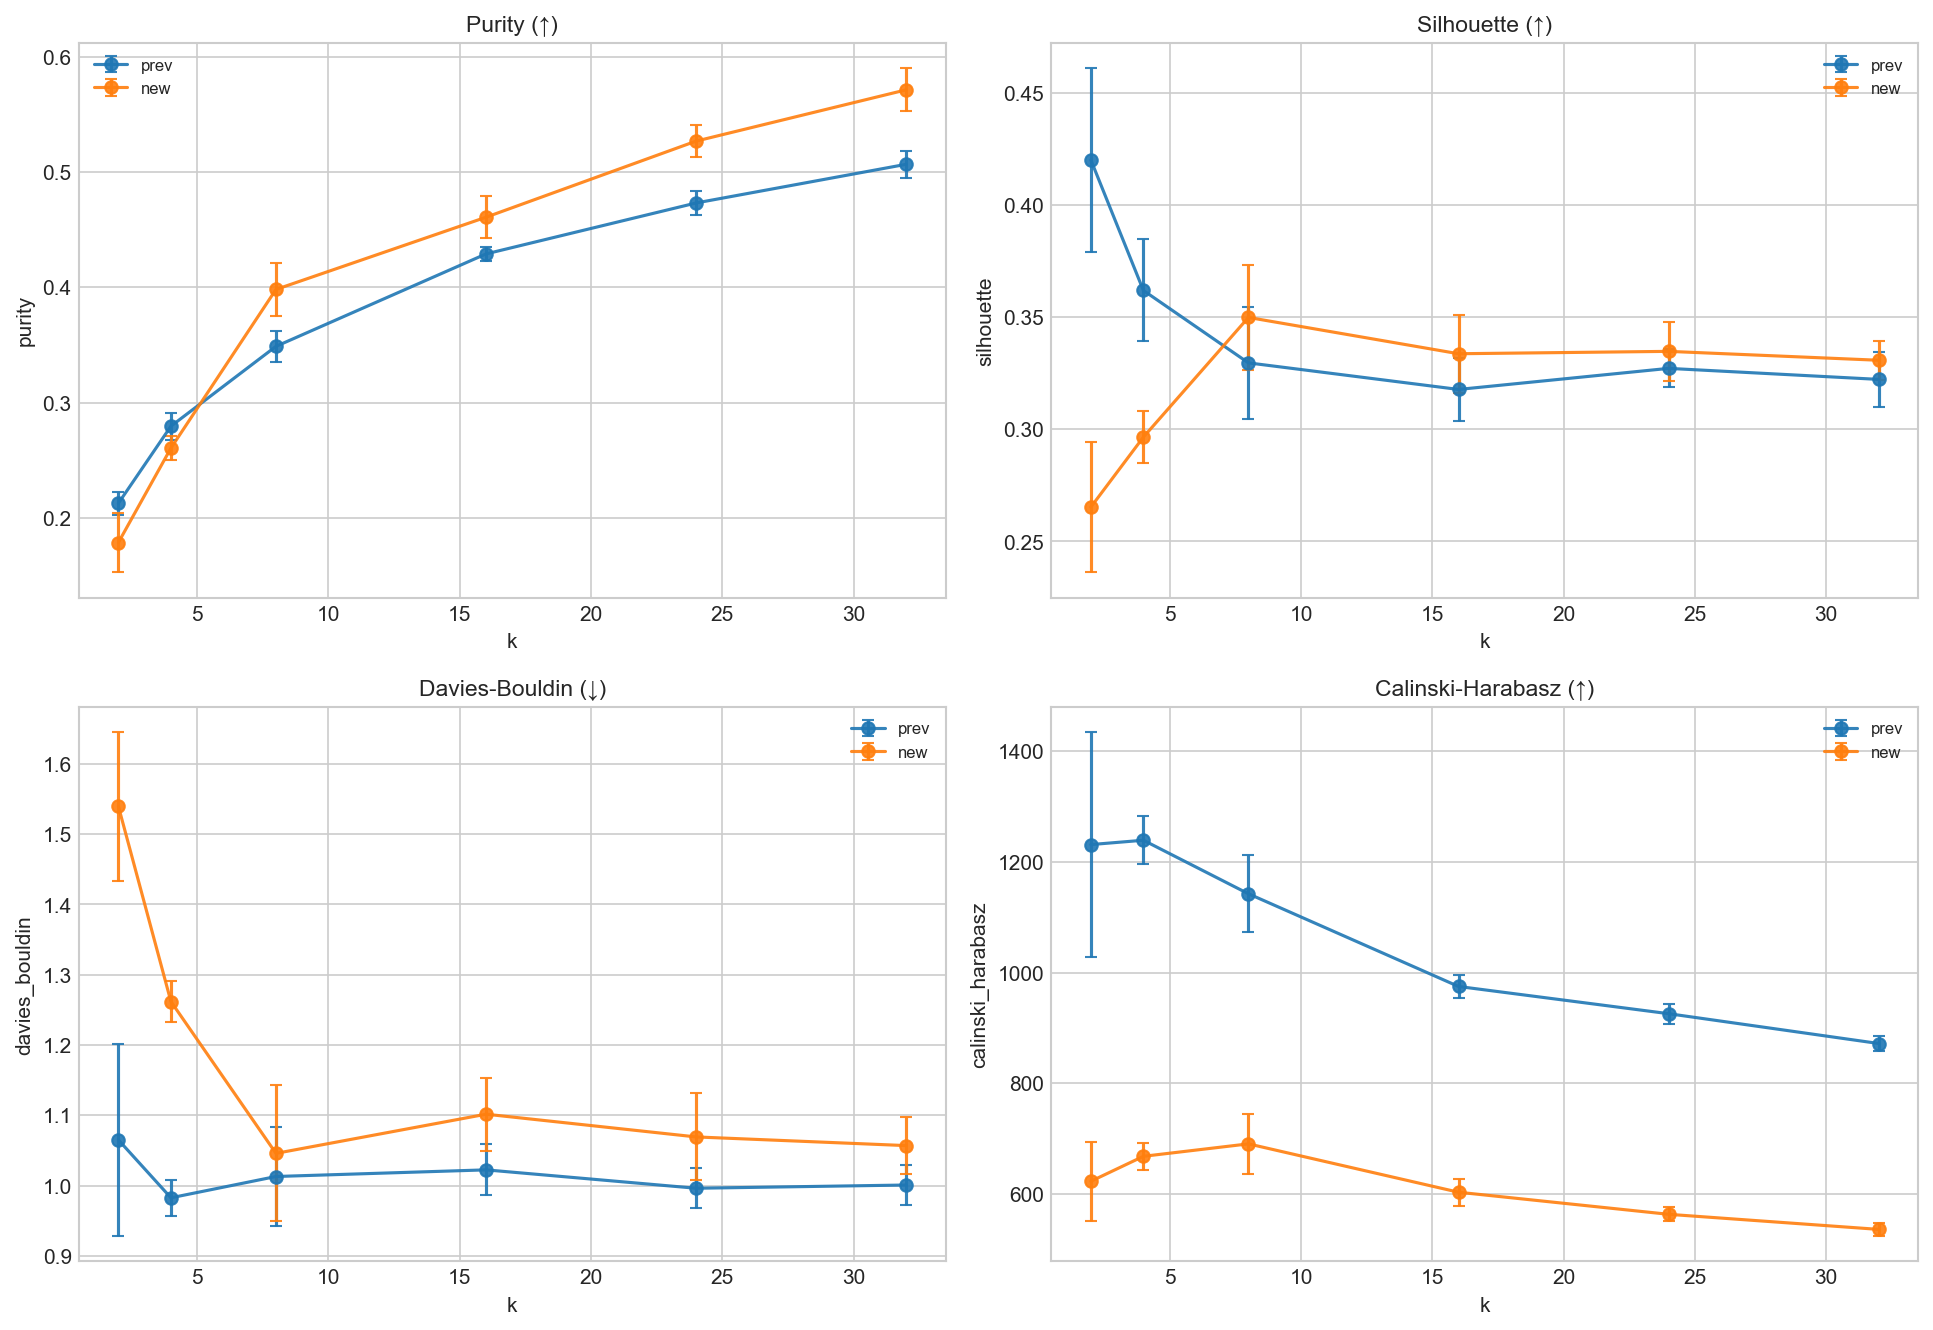


▸ Per-type Δpurity at k=32


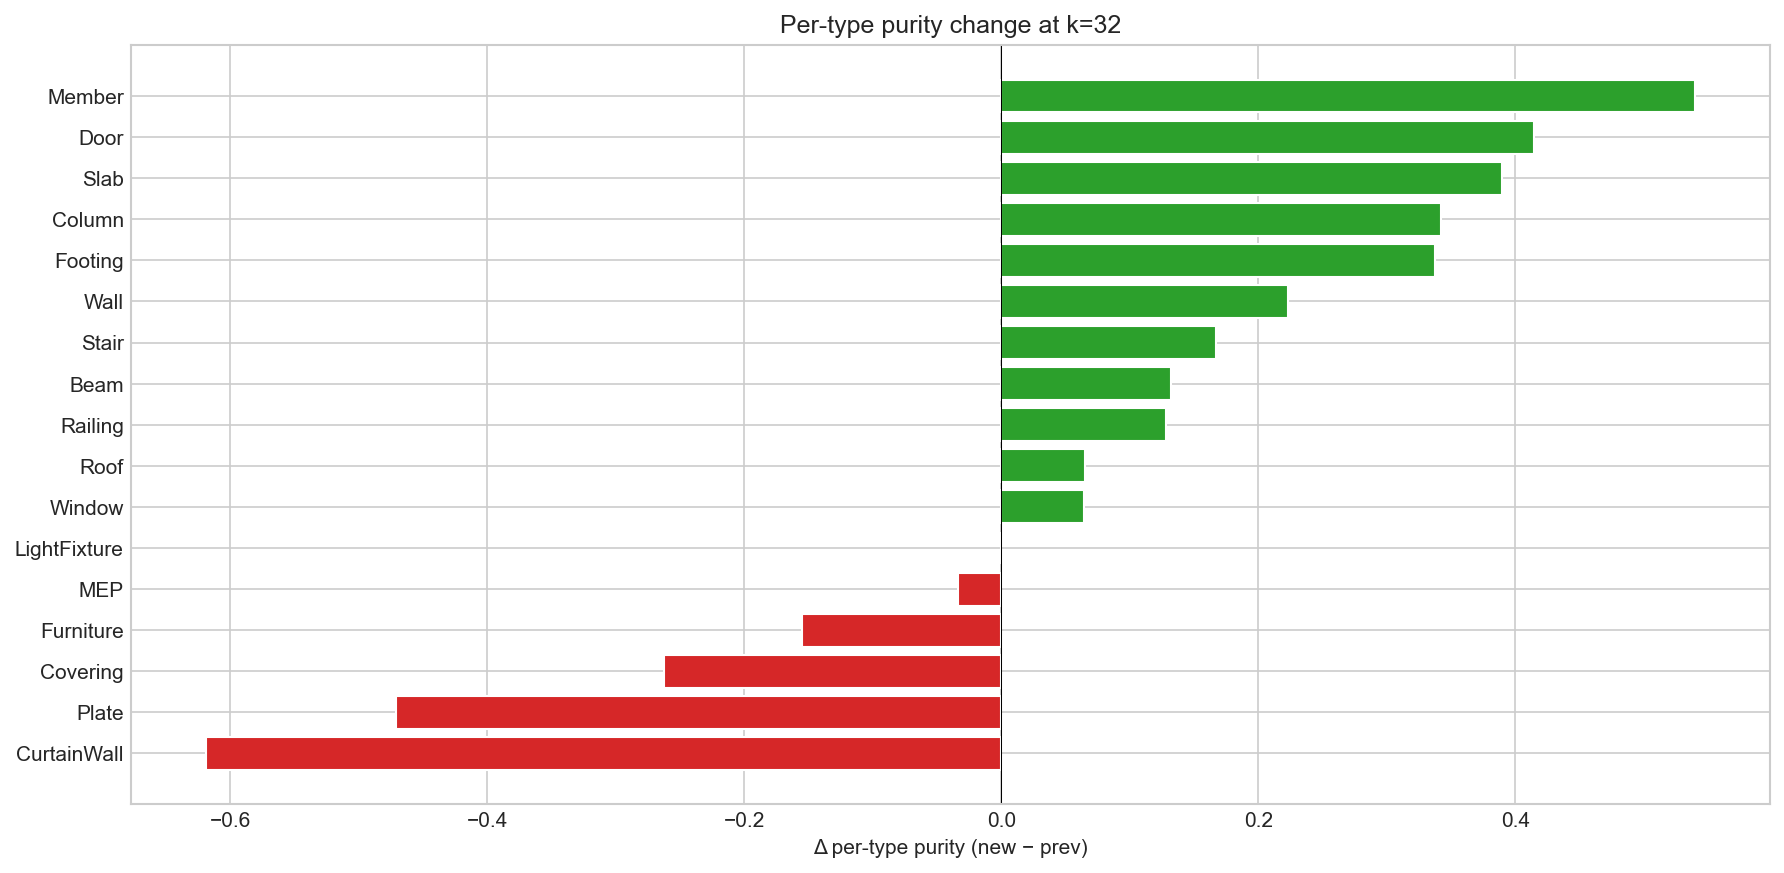


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  + CS Ratio (7)   (02_cs_aspect_ratio)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ Pre-state failure


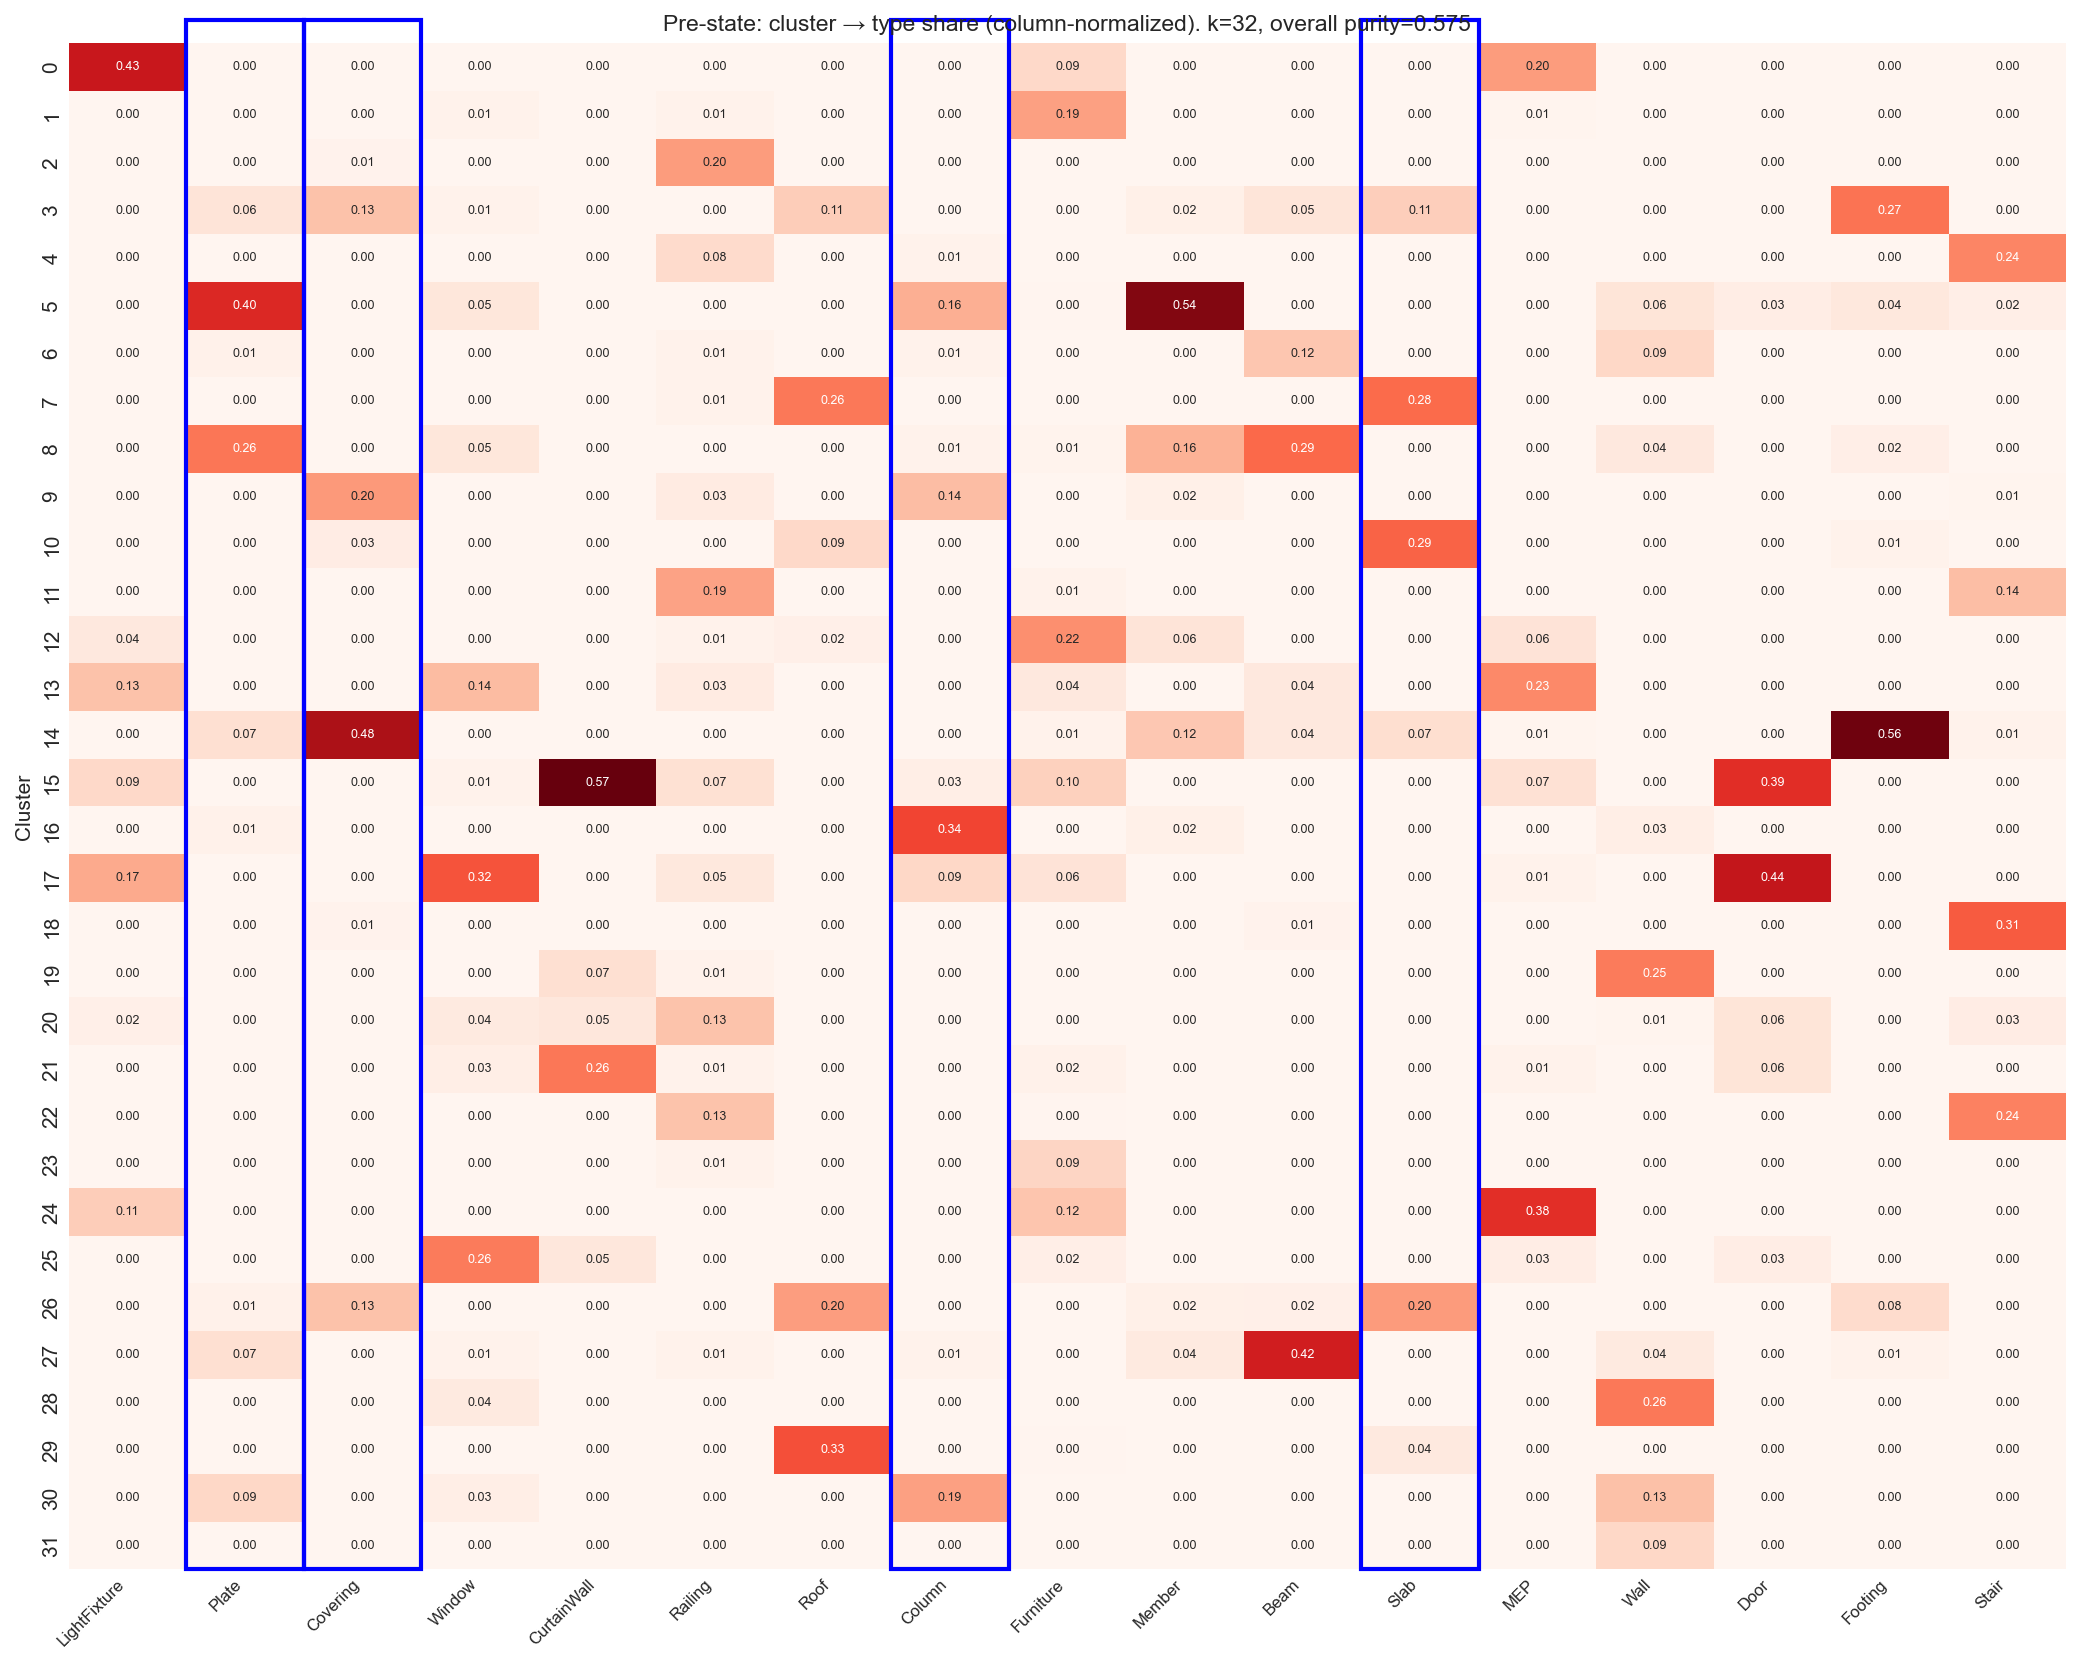


▸ cs_aspect_ratio by merged type


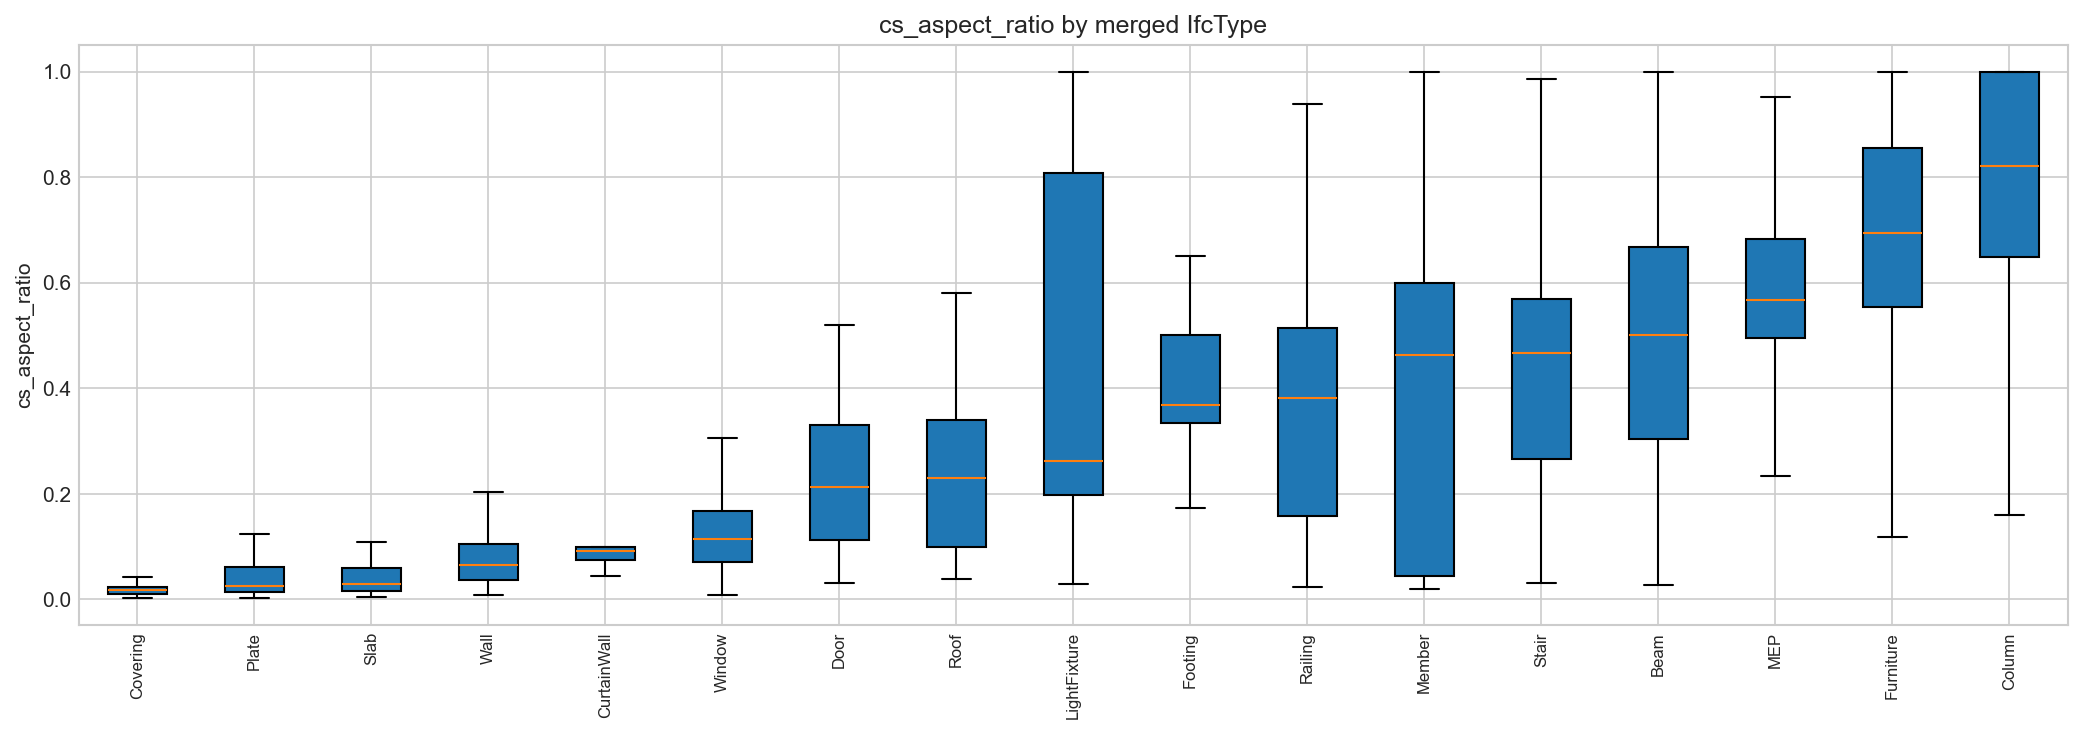


▸ Separation potential (ANOVA F)


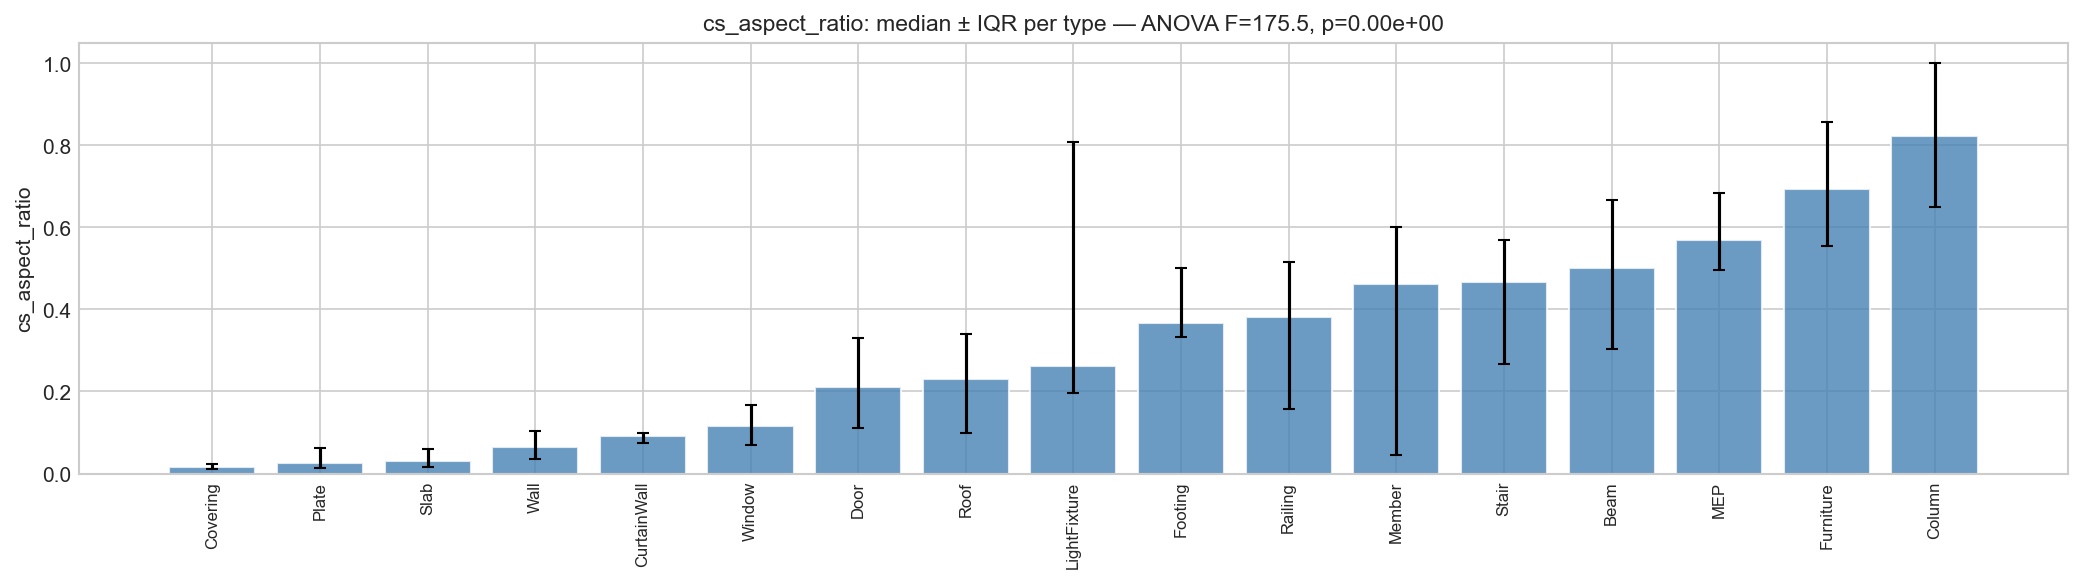


▸ k-sweep prev vs new


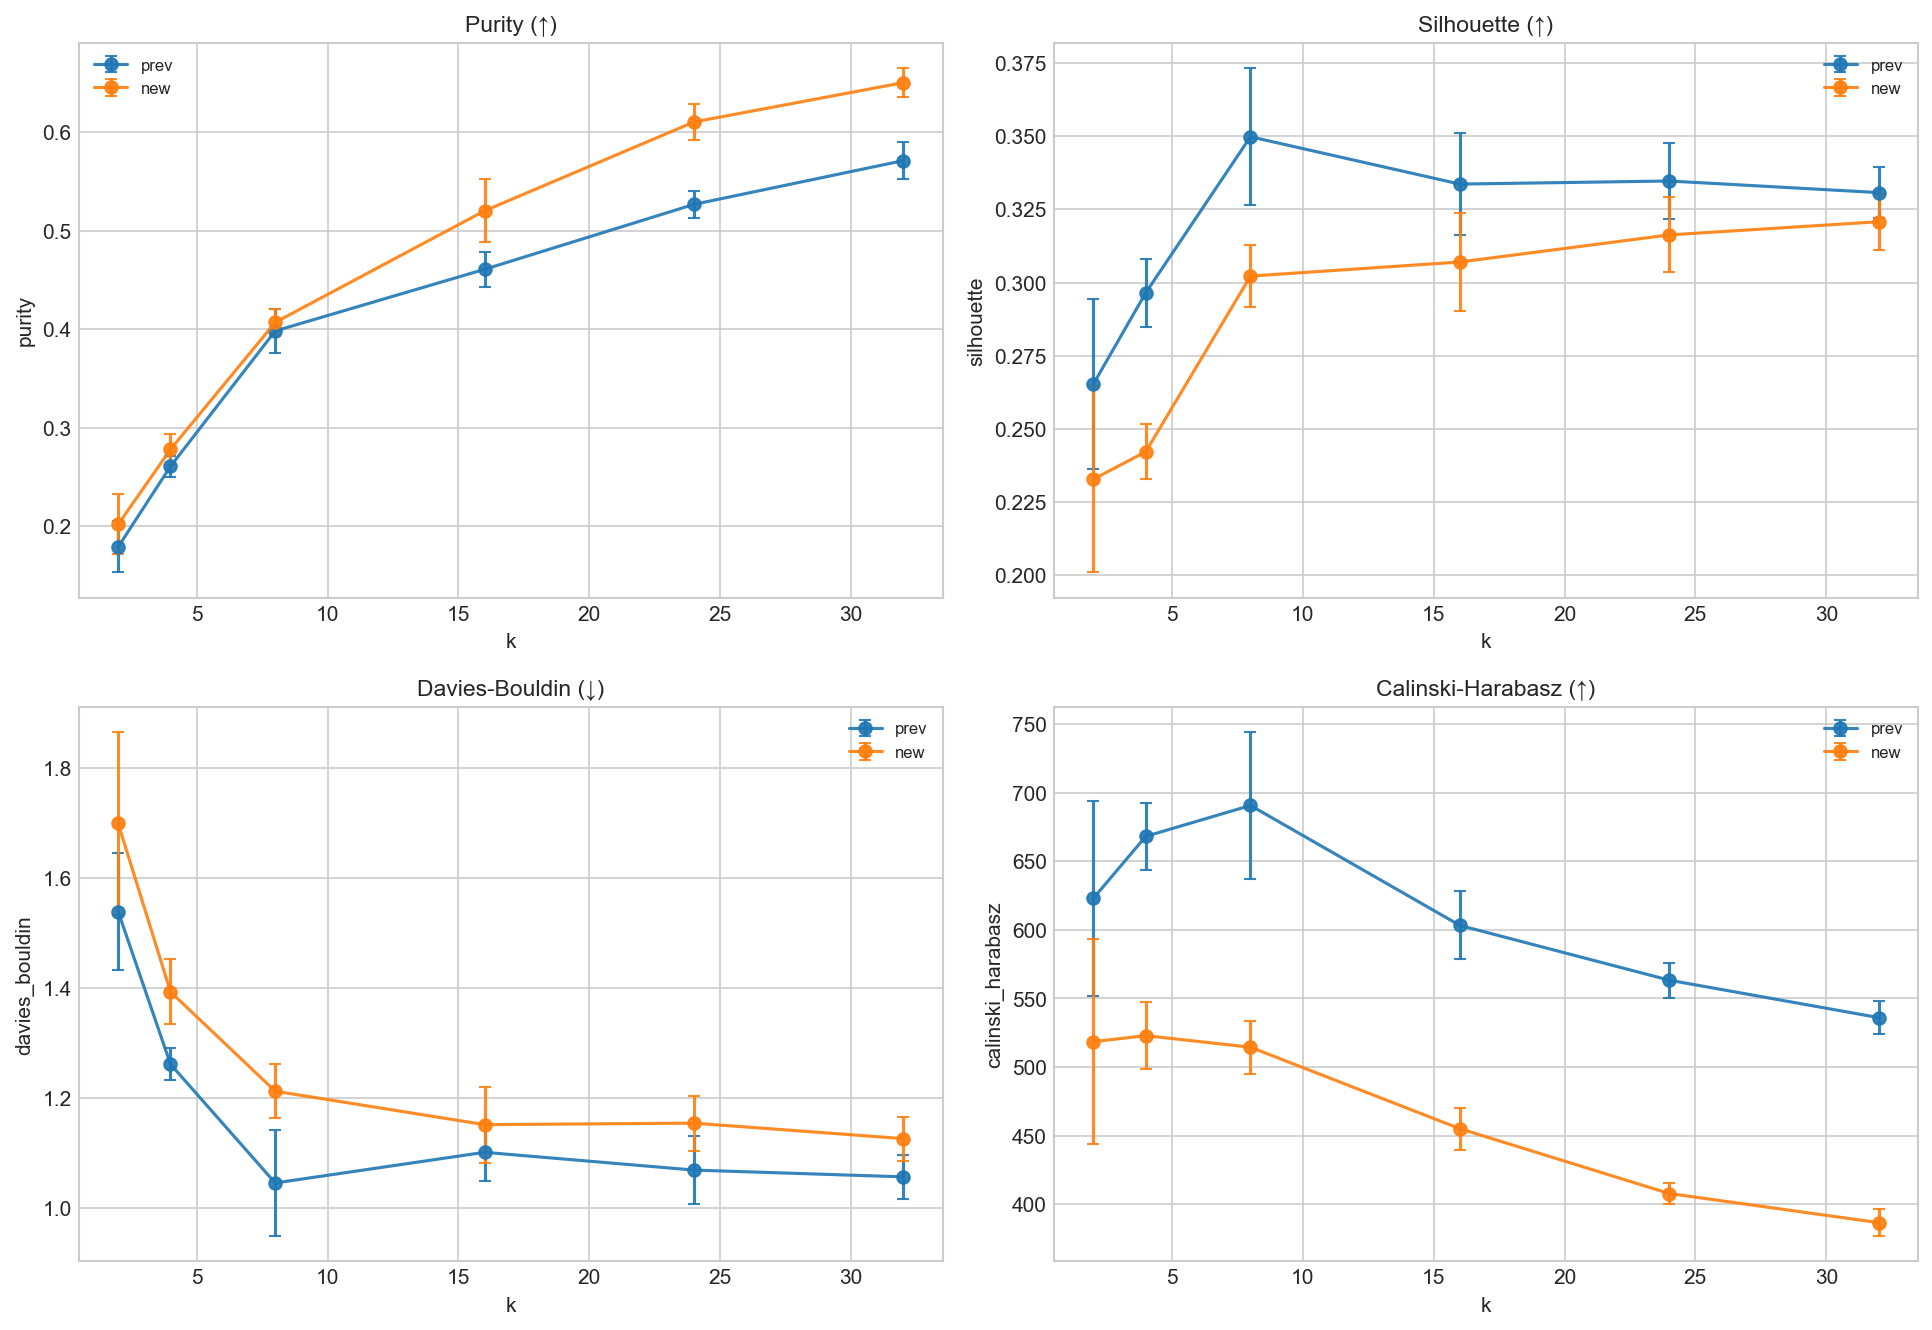


▸ Per-type Δpurity at k=32


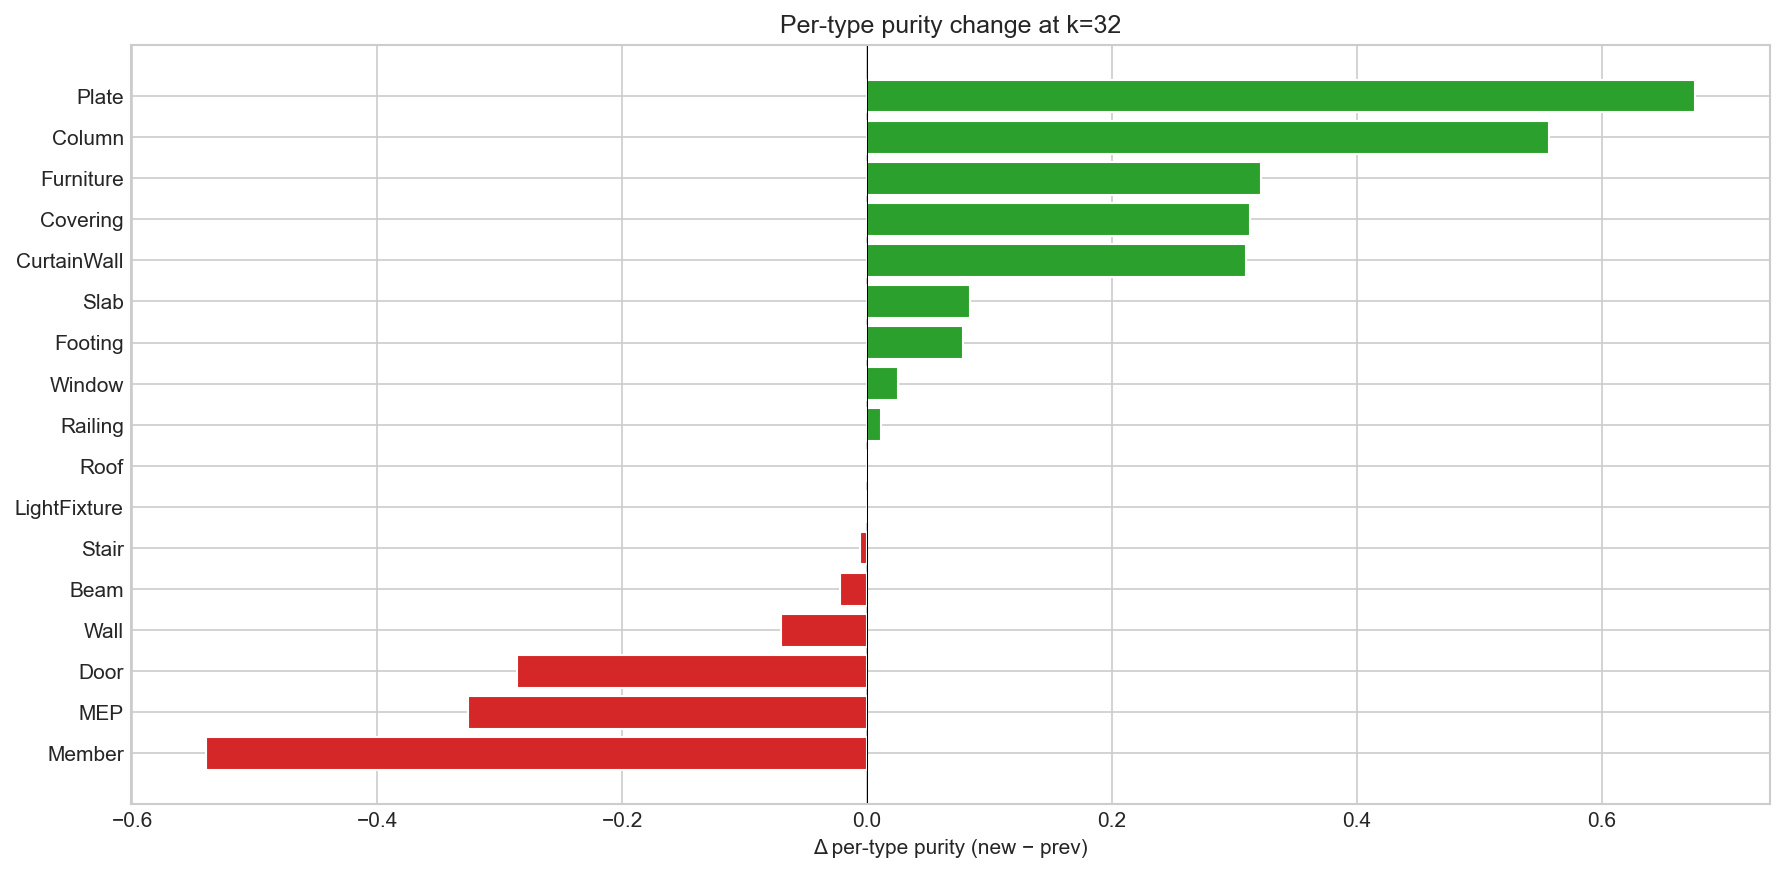


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  + Normal Entropy (8)   (03_normal_entropy)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ Pre-state failure


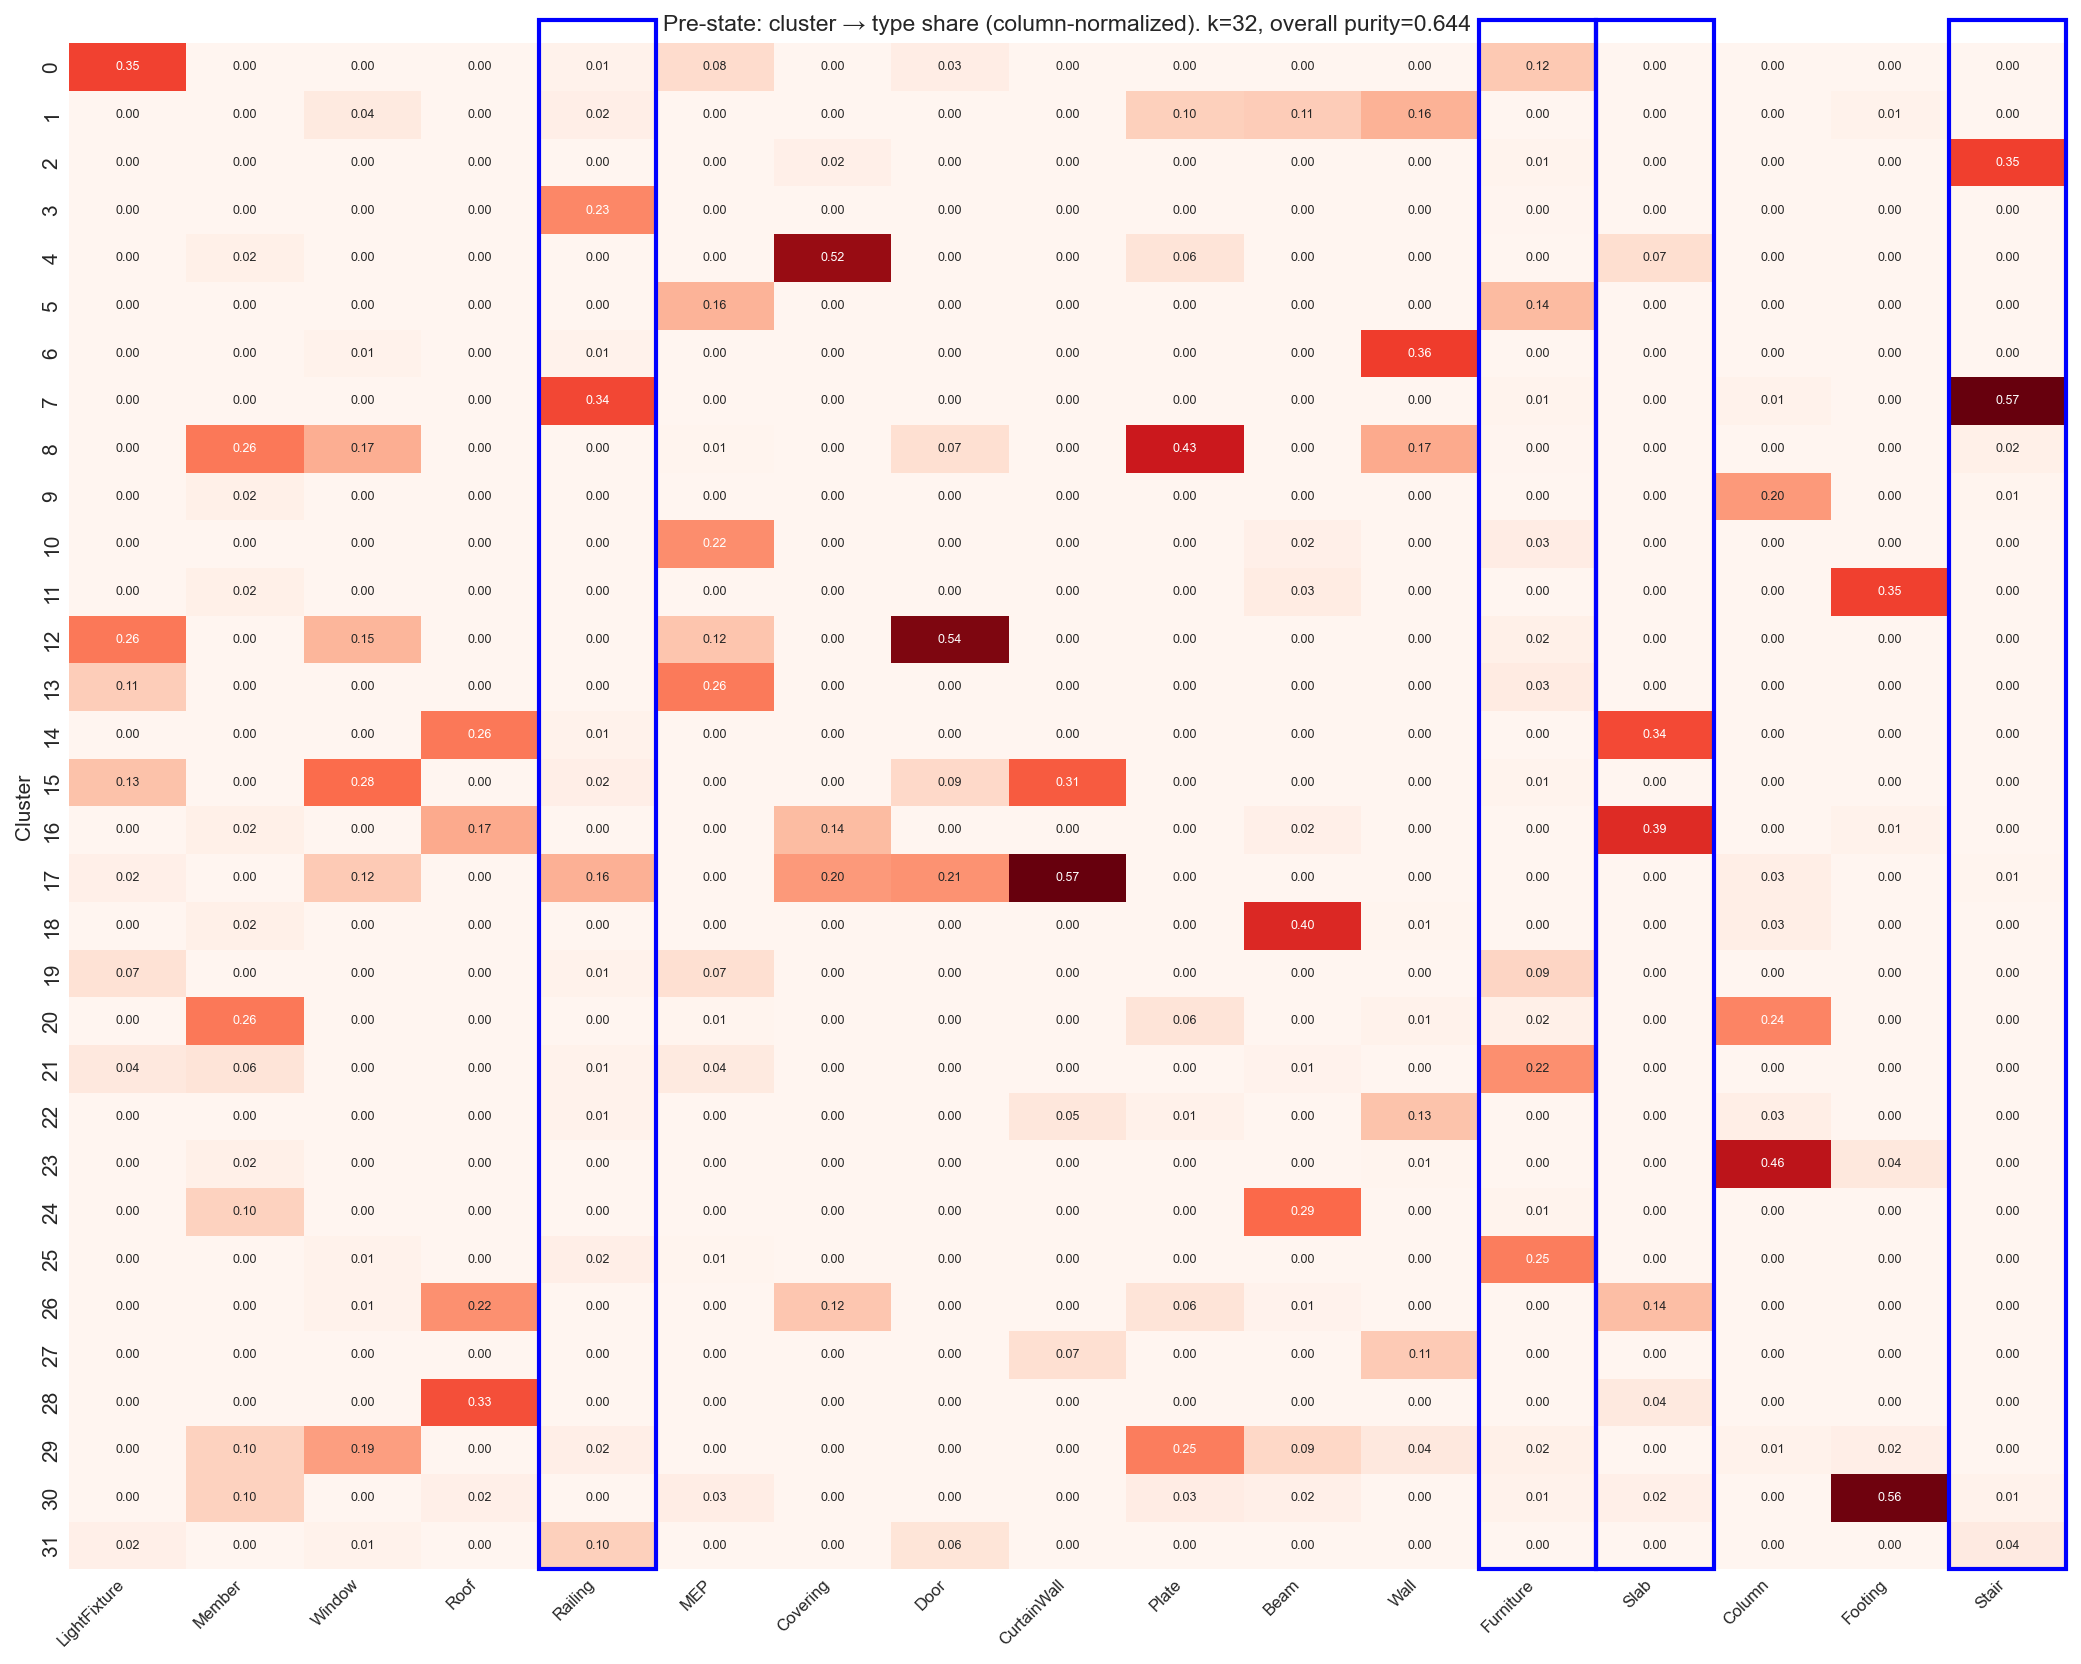


▸ normal_entropy by merged type


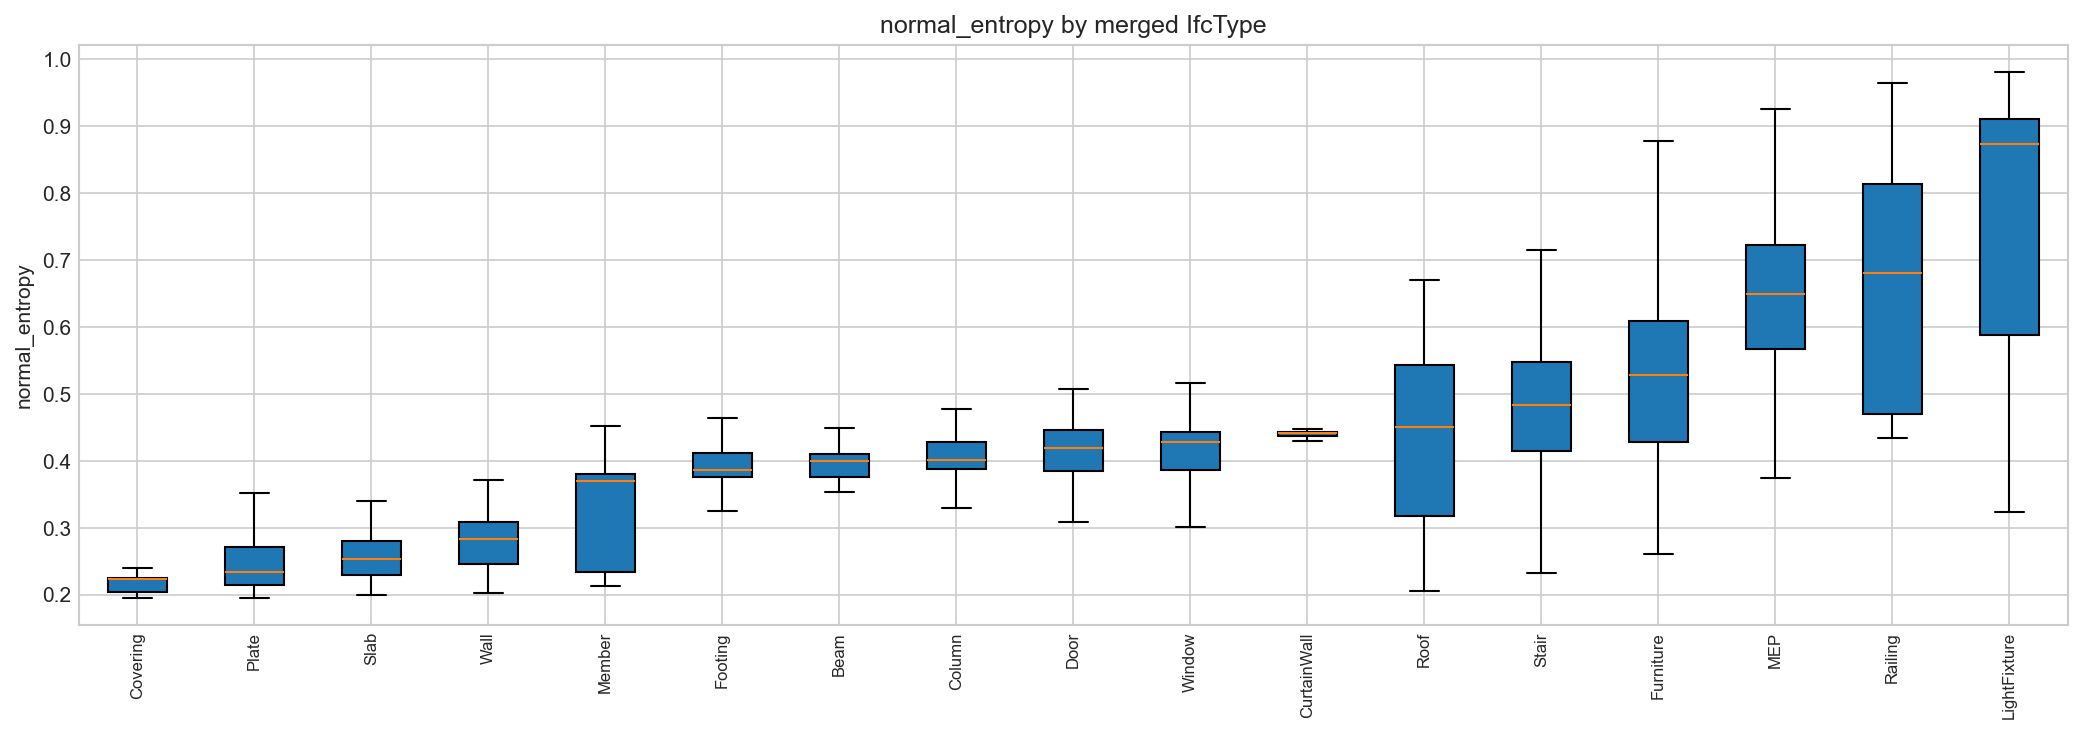


▸ Separation potential (ANOVA F)


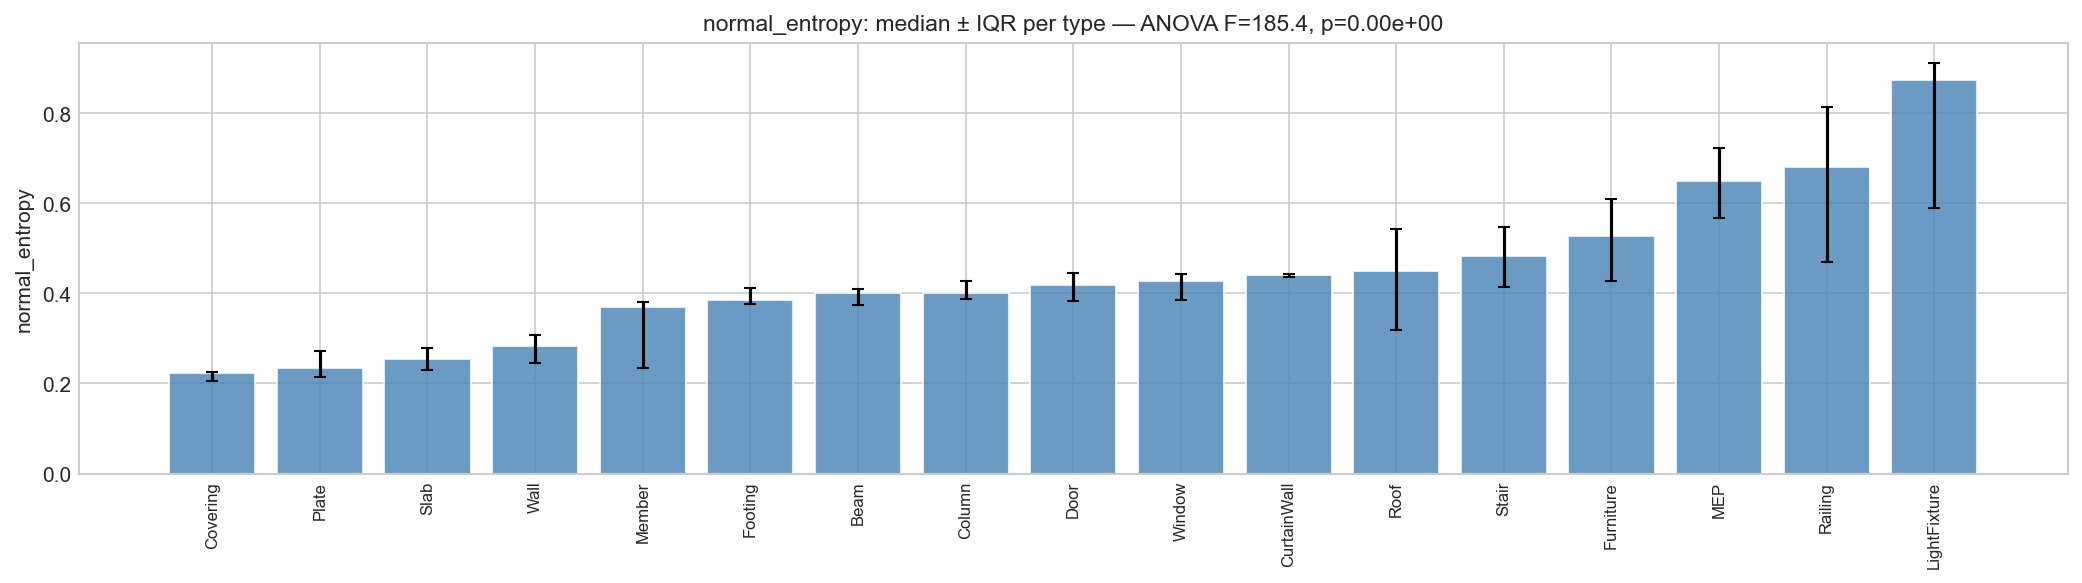


▸ k-sweep prev vs new


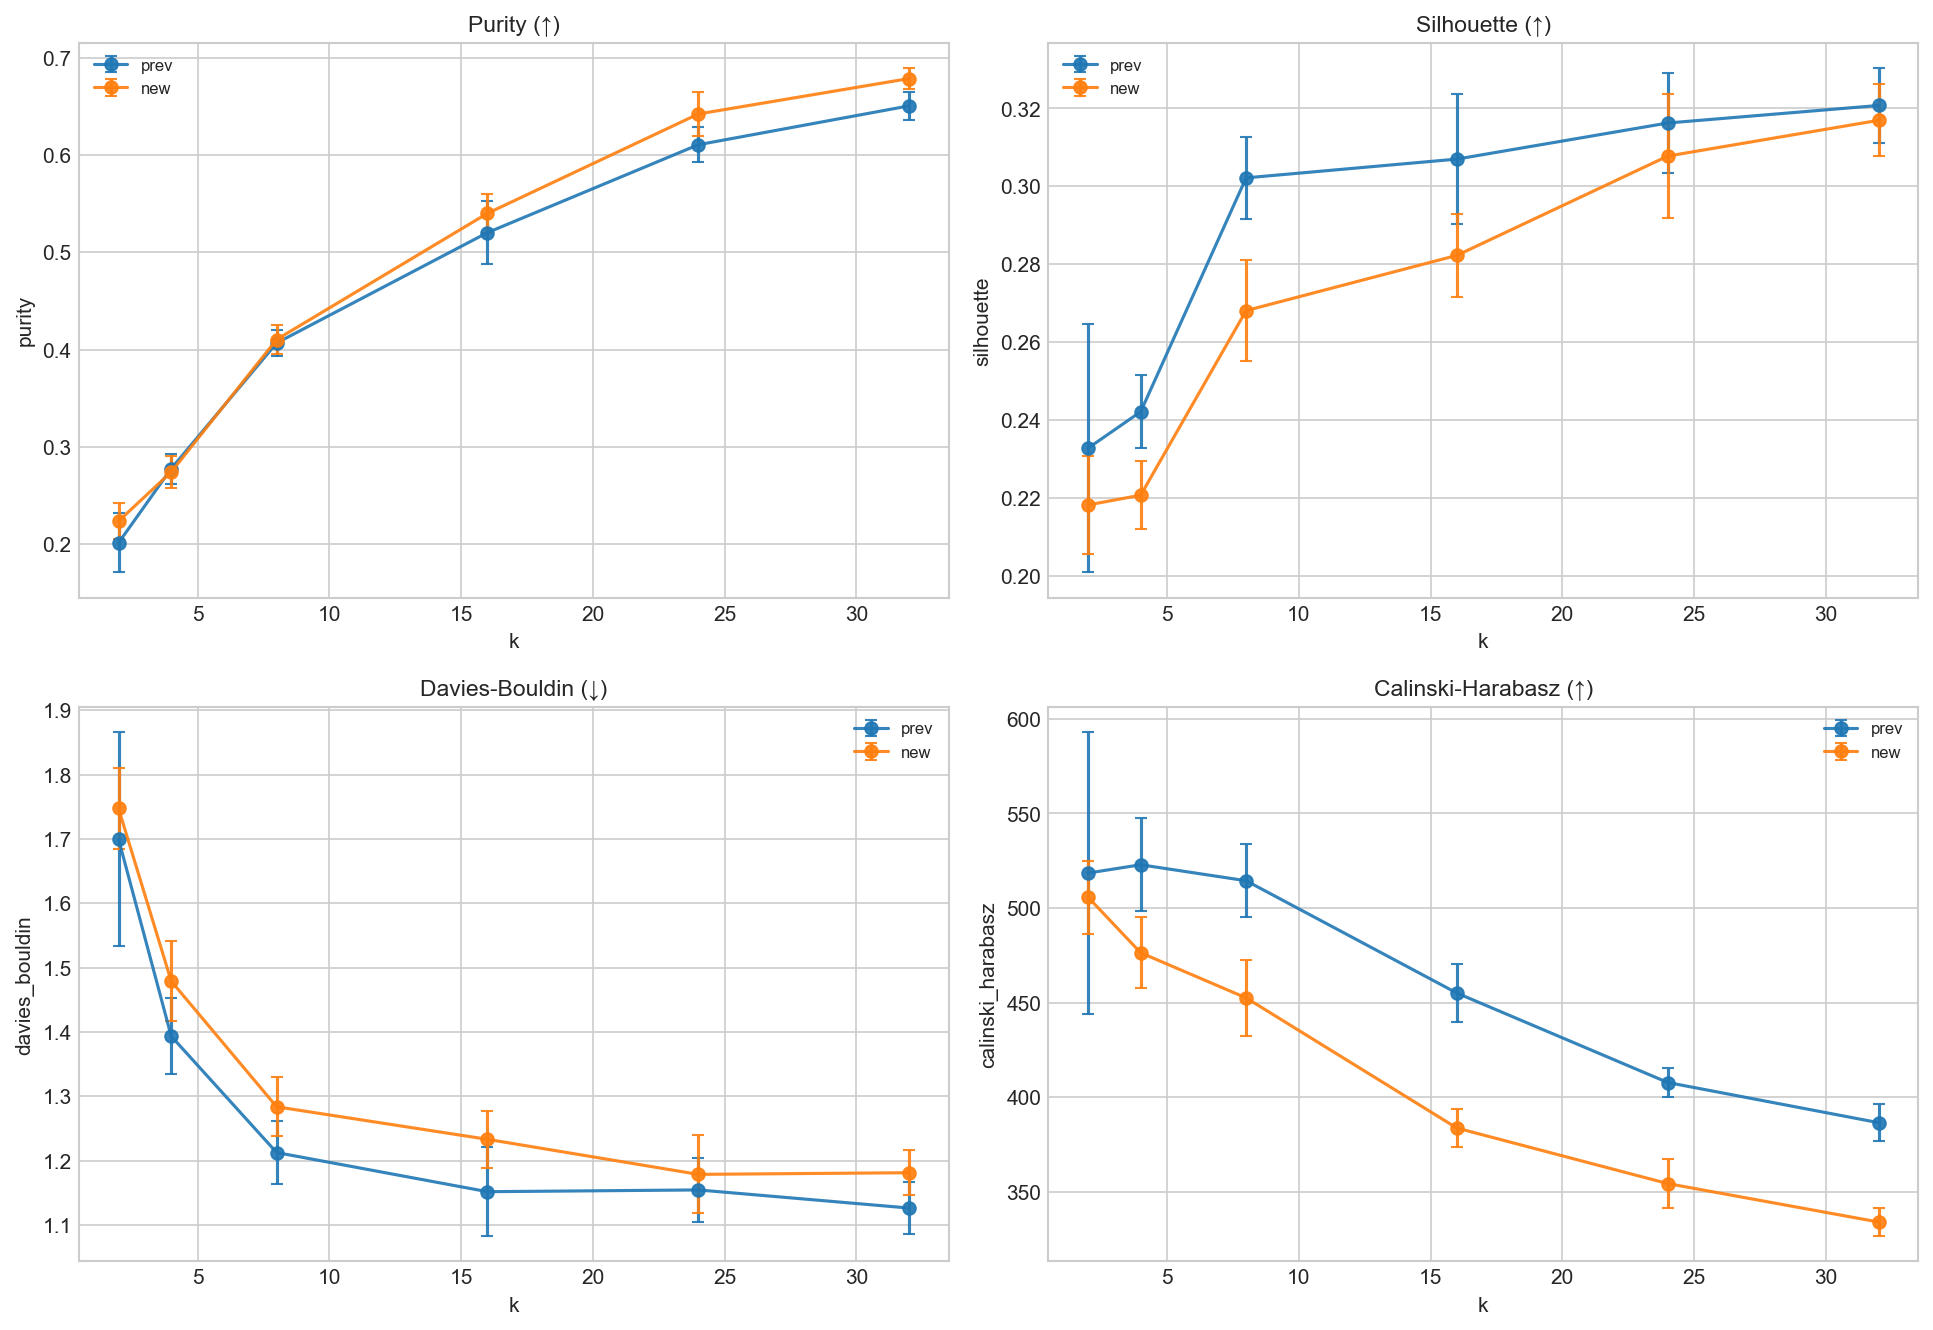


▸ Per-type Δpurity at k=32


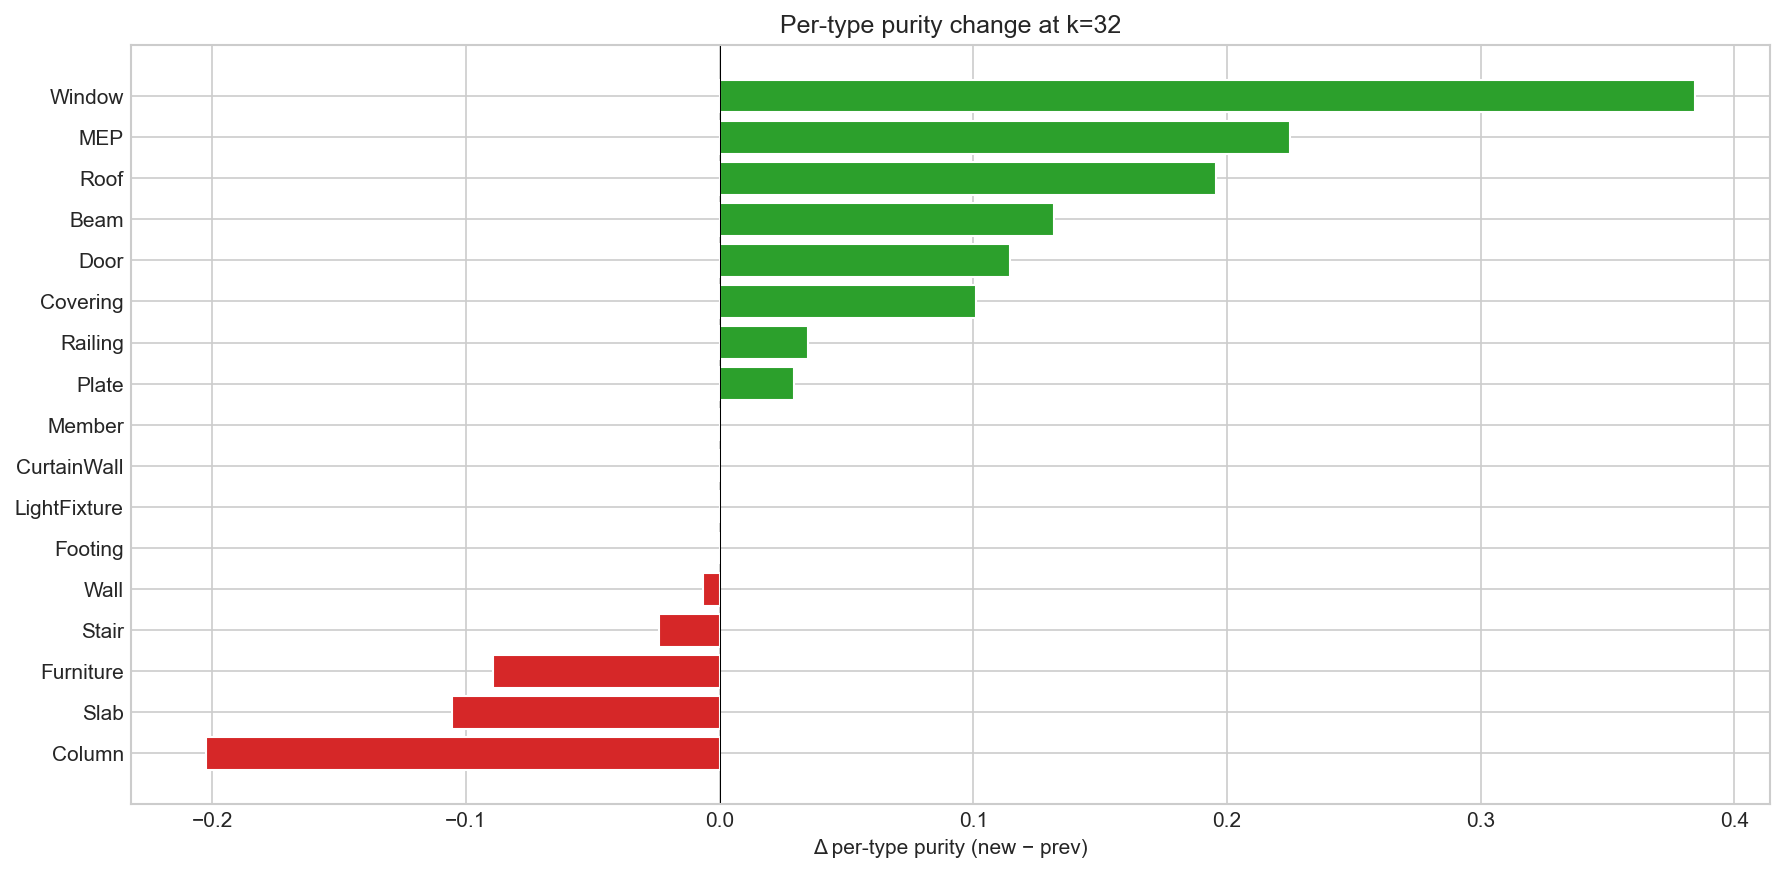


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  + Horiz Frac (9)   (04_horiz_frac)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ Pre-state failure


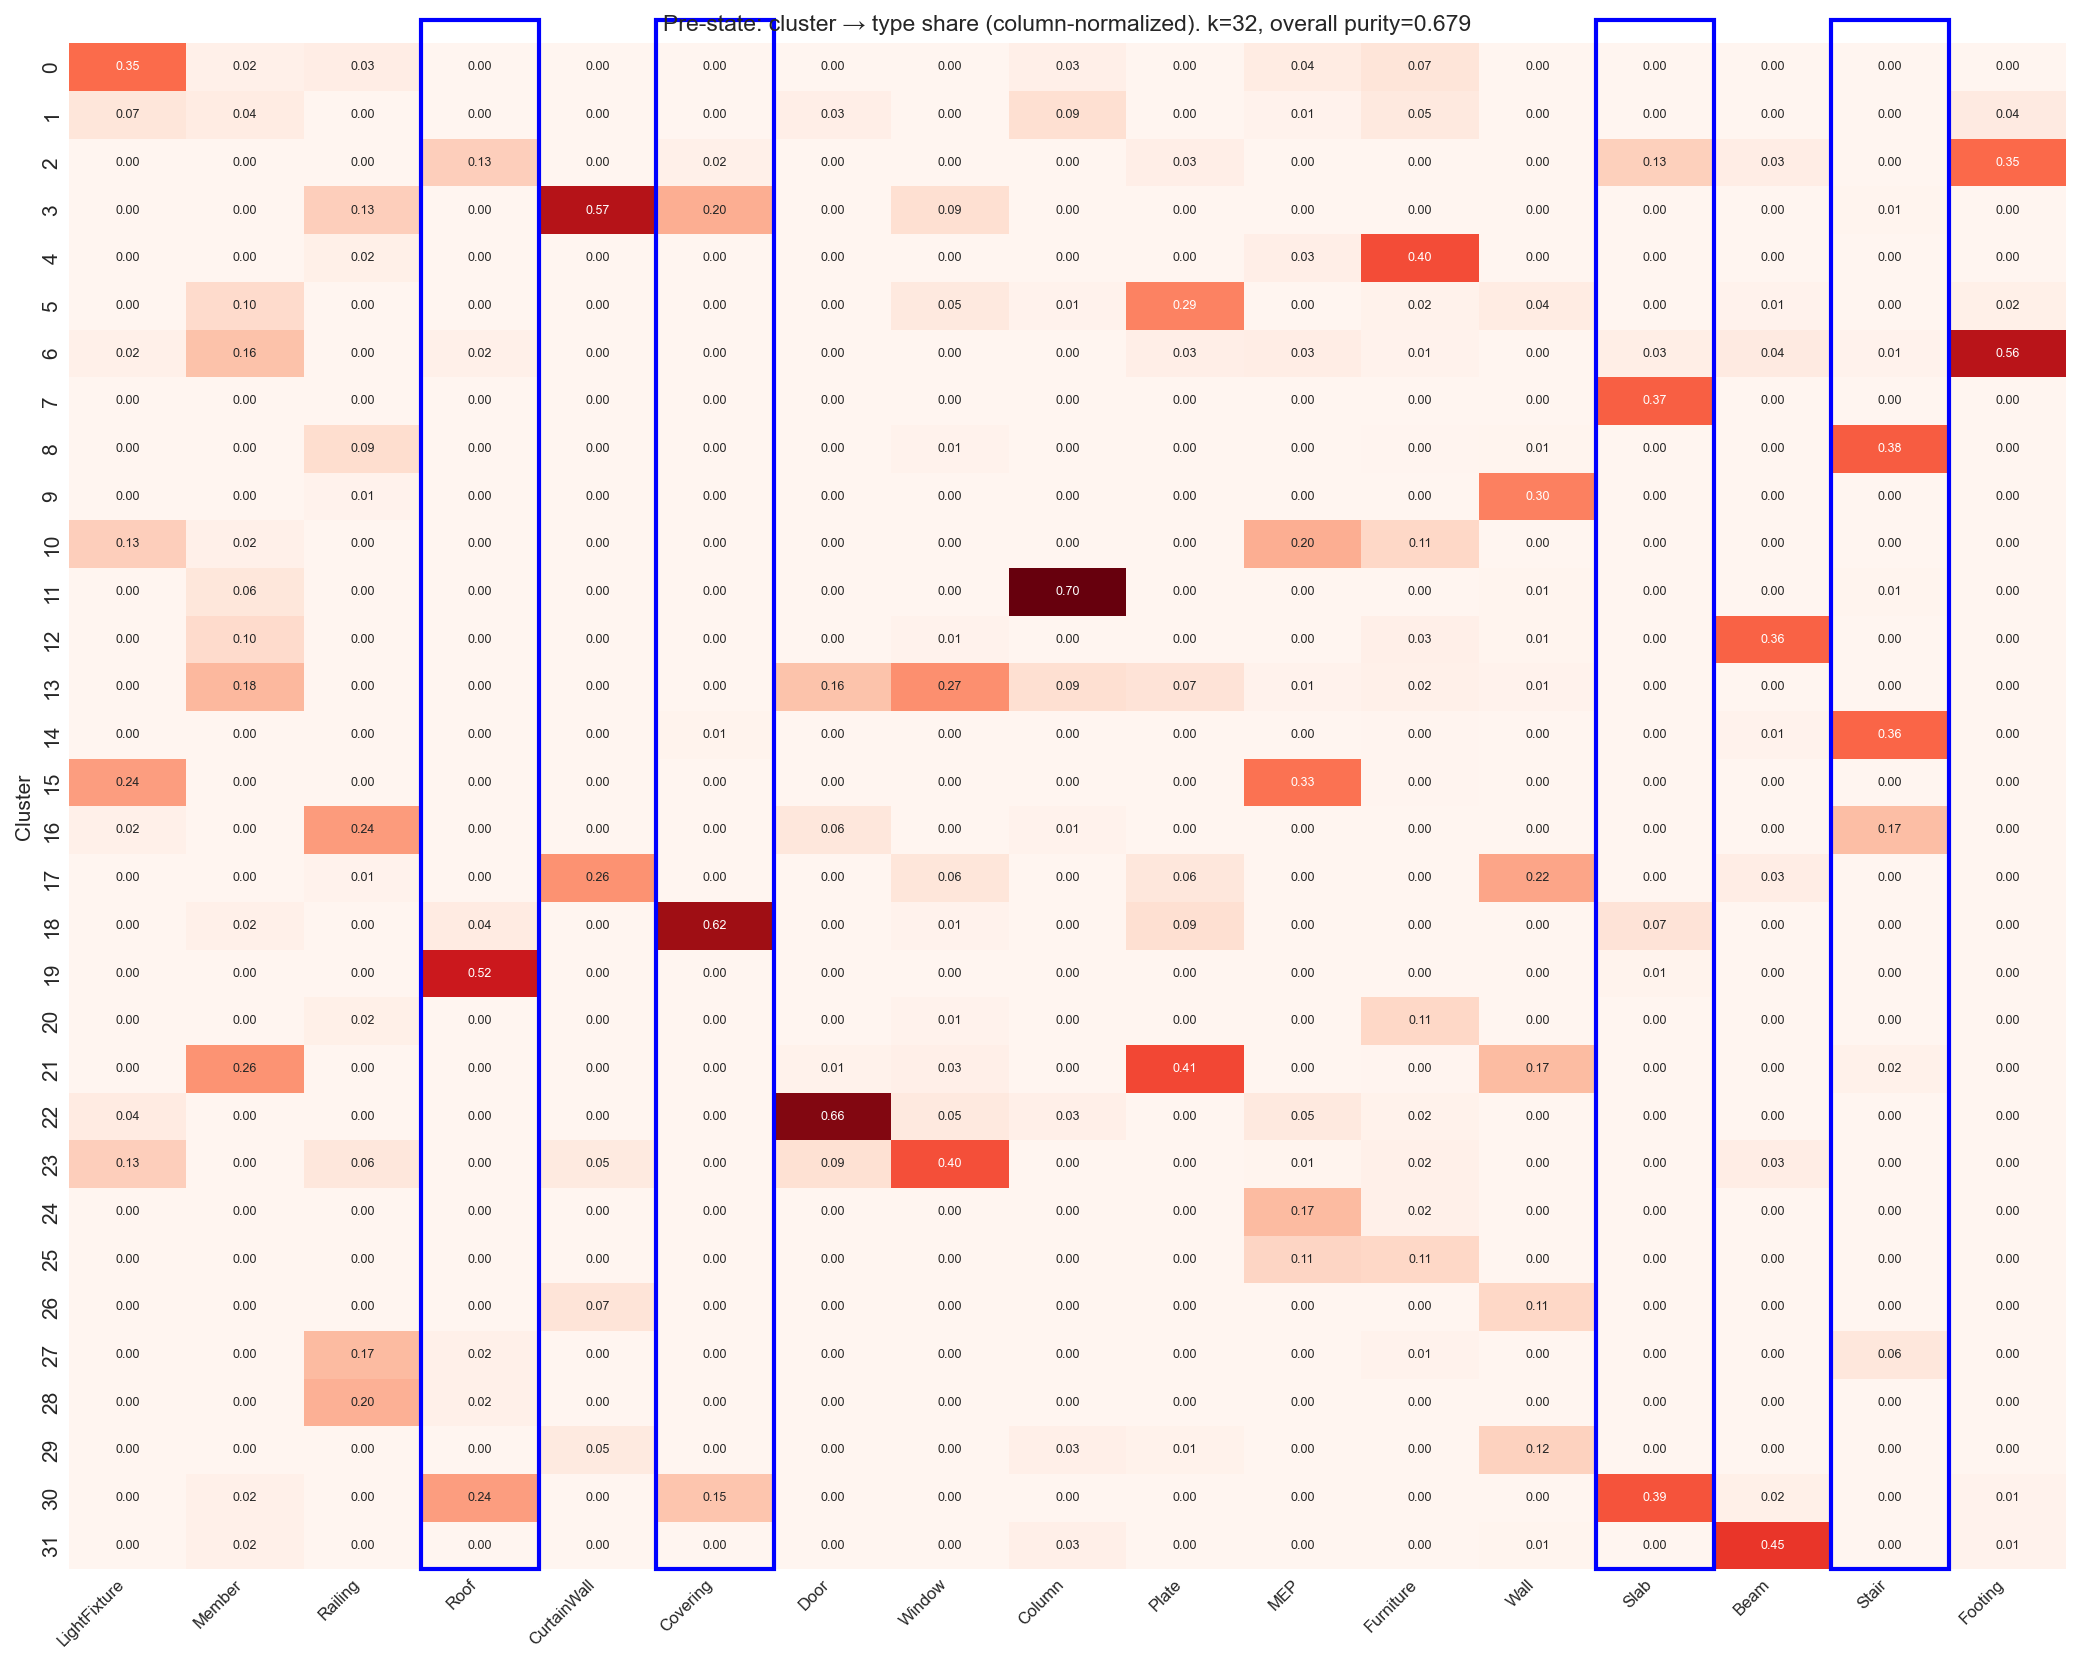


▸ horiz_frac by merged type


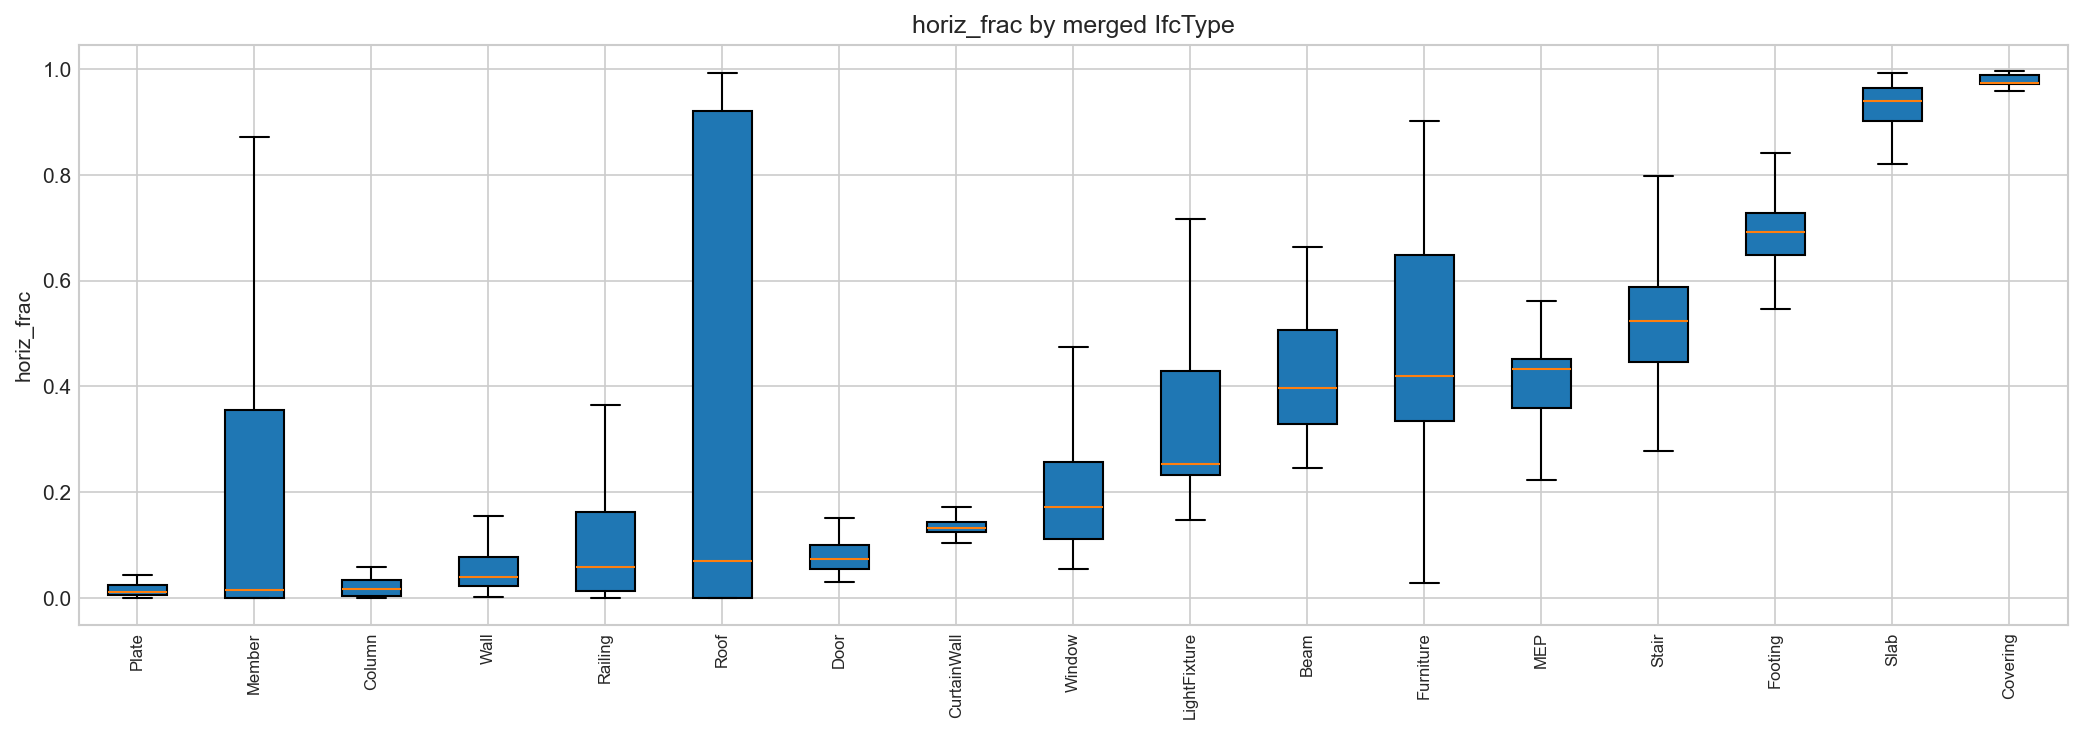


▸ Separation potential (ANOVA F)


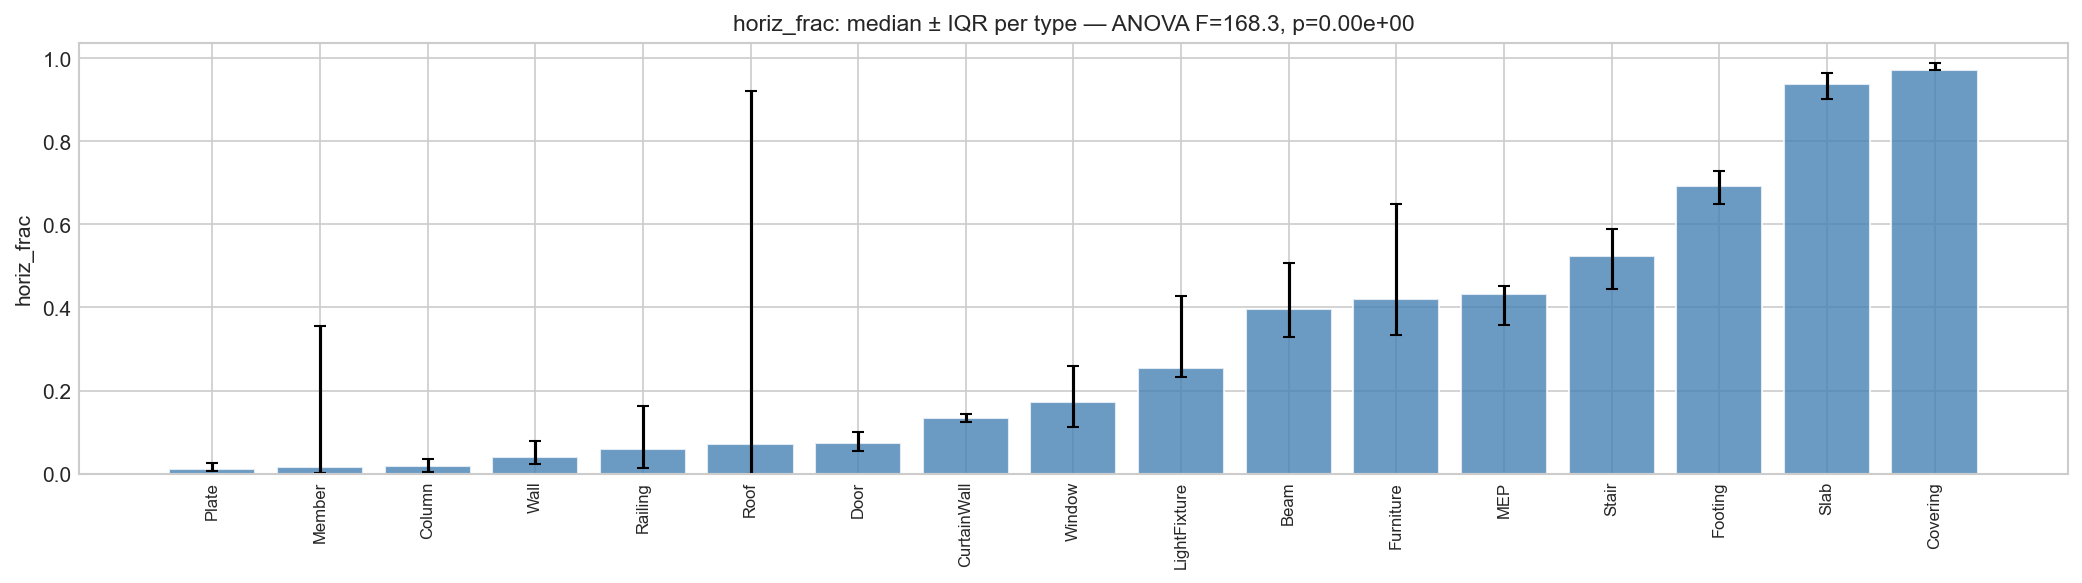


▸ k-sweep prev vs new


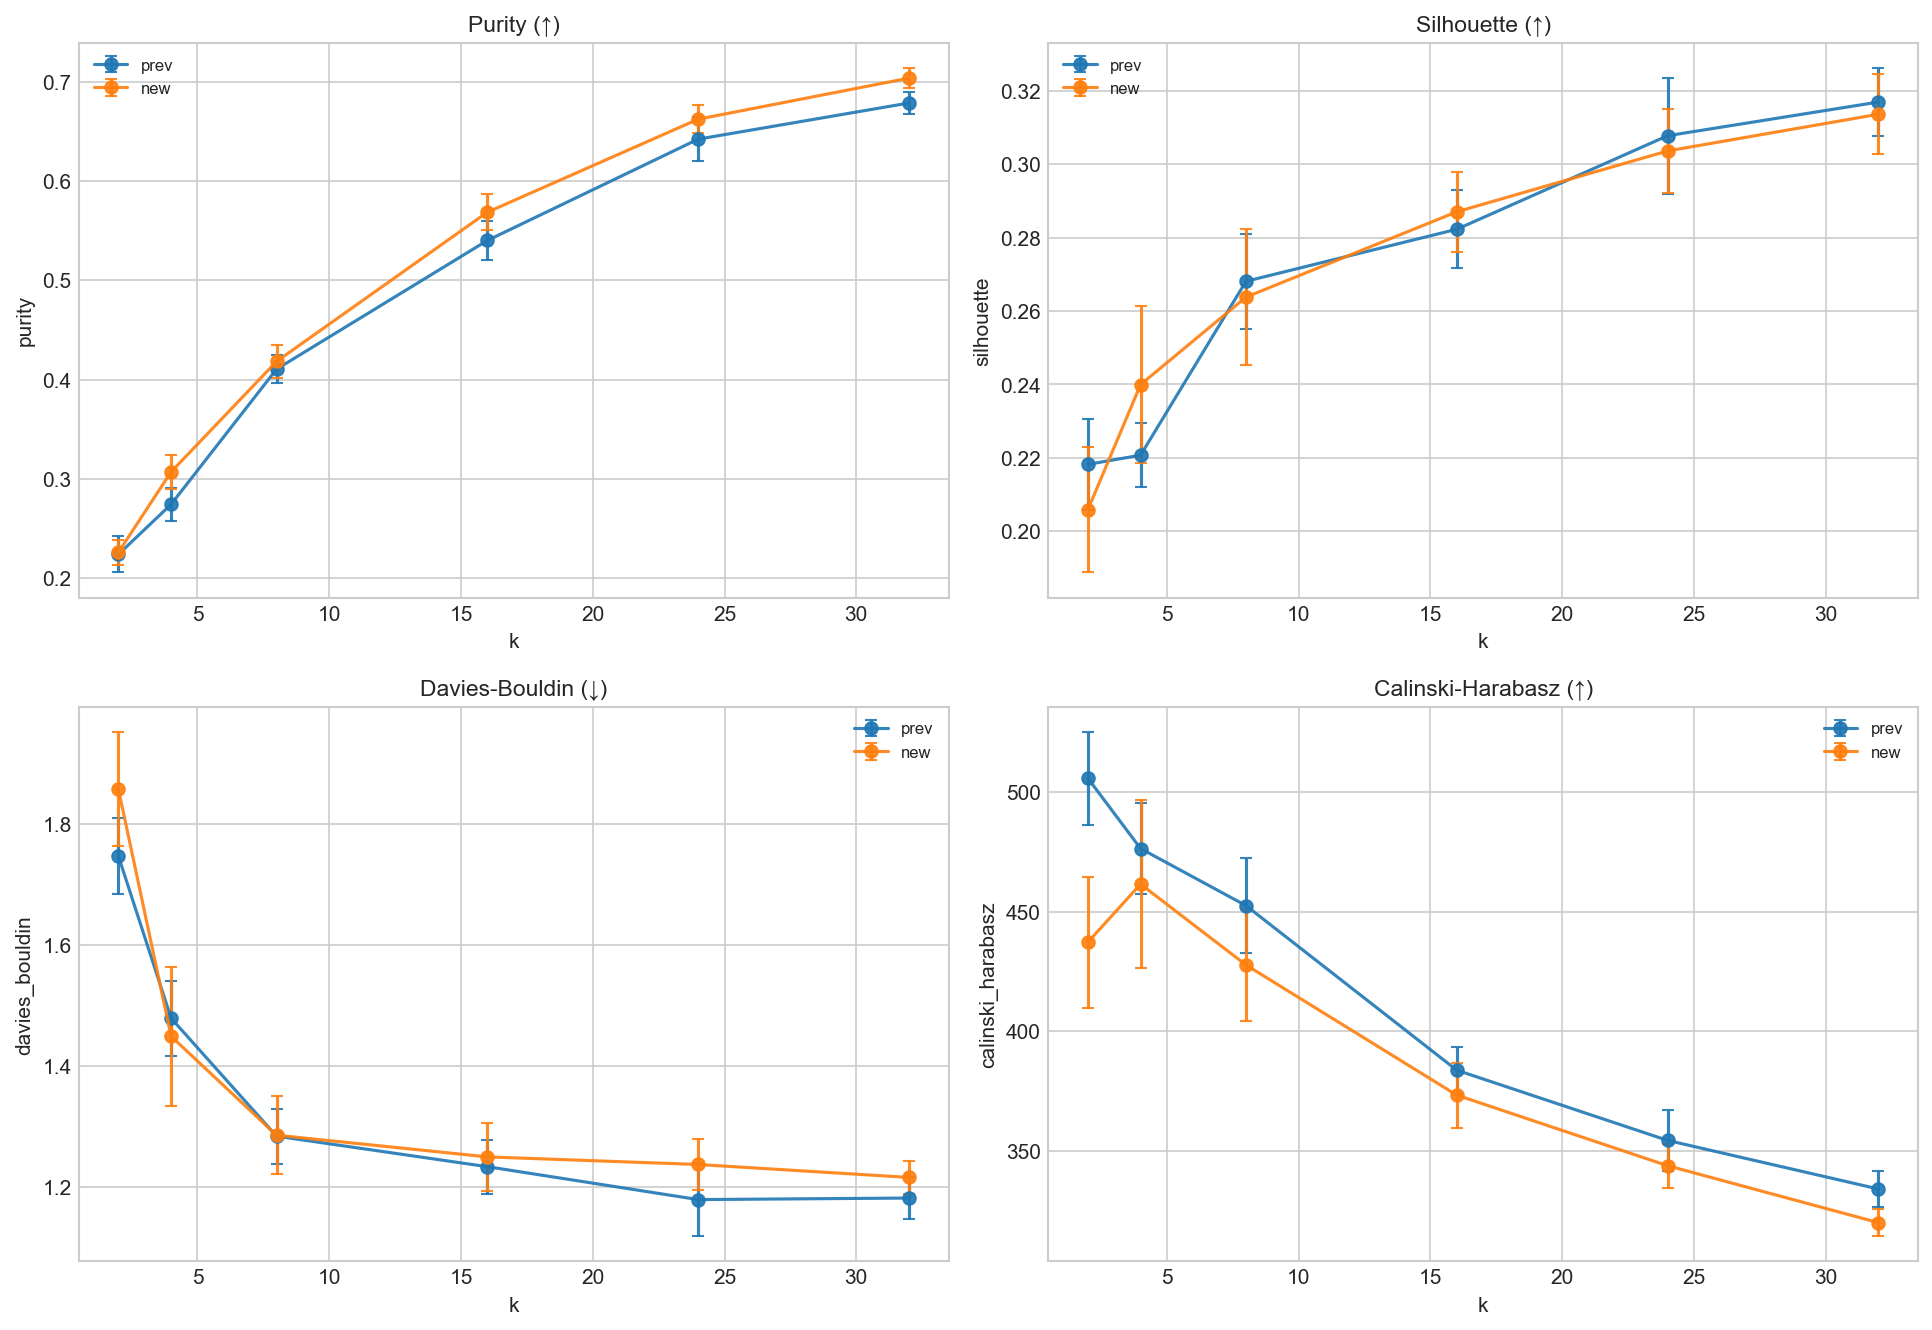


▸ Per-type Δpurity at k=32


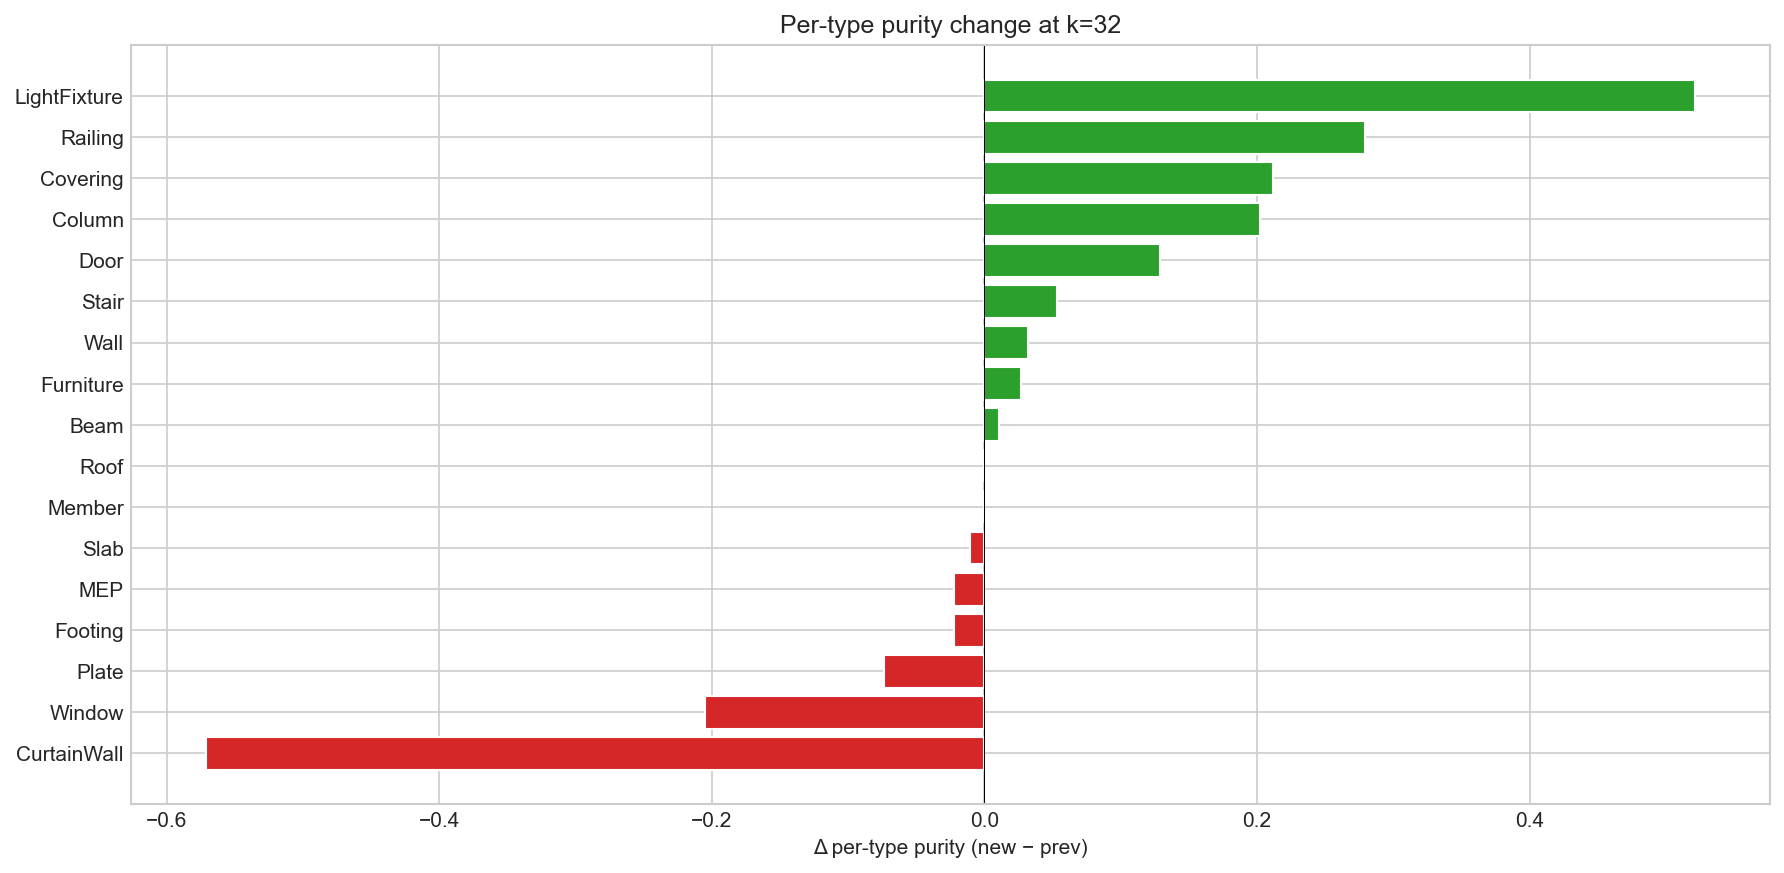

In [10]:
def show_stage(stage_id, config_name, new_feats):
    stage_dir = RESULTS_ROOT / stage_id
    print(f'\n{"━"*78}\n  {config_name}   ({stage_id})\n{"━"*78}')
    fig_list = [
        ('pre_state_failure.png',                              'Pre-state failure'),
    ] + [
        (f'distribution_by_type_{f}.png', f'{f} by merged type') for f in new_feats
    ] + [
        ('separation_potential.png',                           'Separation potential (ANOVA F)'),
        ('k_sweep_metrics.png',                                'k-sweep prev vs new'),
        (f'per_type_delta_k{K_MAIN}.png',                      f'Per-type Δpurity at k={K_MAIN}'),
    ]
    for fname, caption in fig_list:
        p = stage_dir / fname
        if p.exists():
            print(f'\n▸ {caption}')
            display(Image(filename=str(p)))

for stage_id, name, feats in FEATURE_ORDER[1:]:
    show_stage(stage_id, name, feats)

### Baseline scaling evidence (stage 00)

Why log1p + RobustScaler beats alternatives on the 4 OBB features.

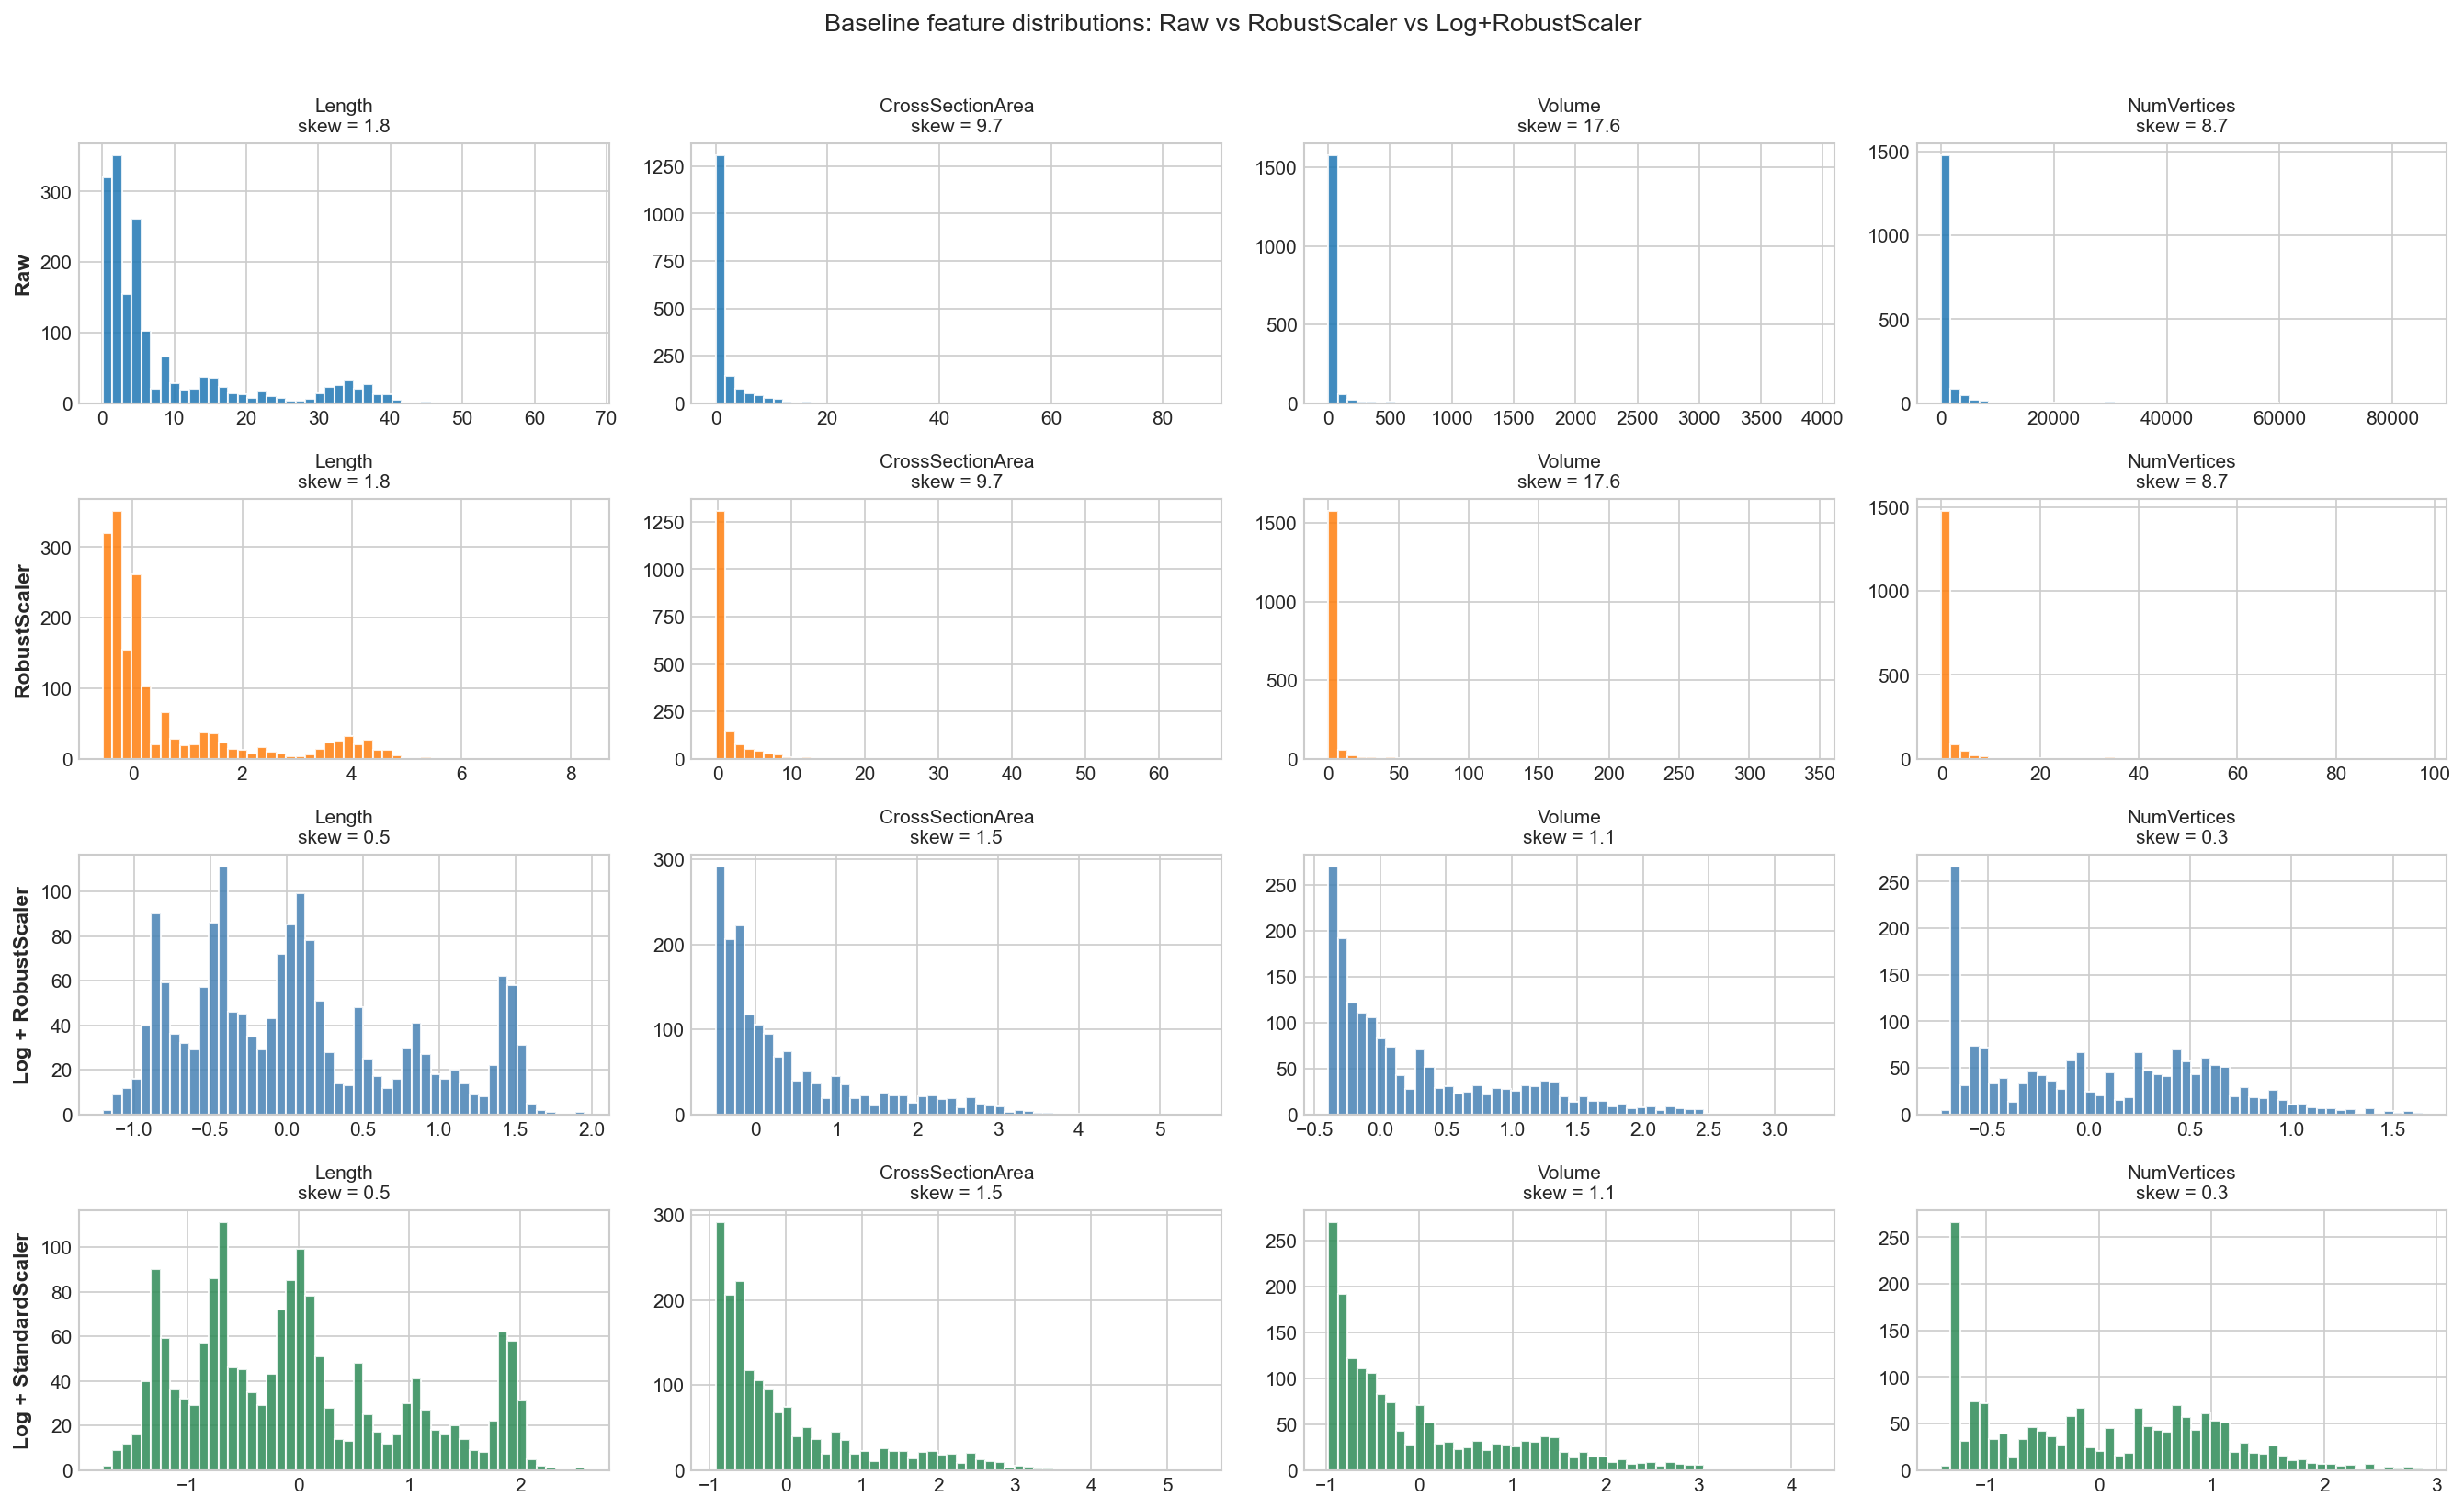

,config,purity_mean,silhouette_mean,davies_bouldin_mean,calinski_harabasz_mean
0,raw_unscaled,0.356,0.408,0.713,1000.798
1,robust,0.399,0.300,0.882,655.958
2,log_robust,0.518,0.328,0.979,984.250
3,log_standard,0.507,0.322,1.001,872.031


In [11]:
display(Image(filename=str(RESULTS_ROOT / '00_baseline' / 'scaling_comparison.png')))
pd.read_csv(RESULTS_ROOT / '00_baseline' / 'scaling_comparison.csv')[
    ['config', 'purity_mean', 'silhouette_mean', 'davies_bouldin_mean', 'calinski_harabasz_mean']
].round(3)

## 4. Per-type journey

Rows = IFC types, columns = stages. Each cell = per-type purity at k=32 under
that stage's feature set (seed=42; single-seed noise applies).

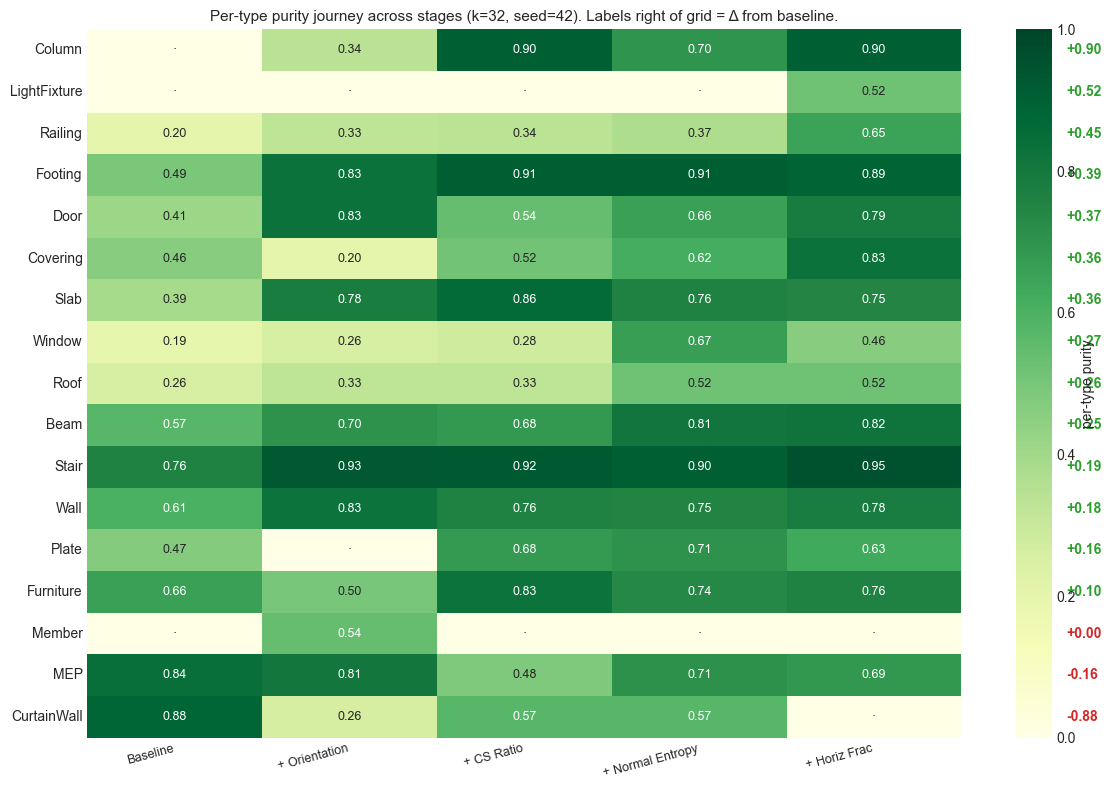

In [12]:
per_type_table = {}
for stage_id, name, _ in FEATURE_ORDER:
    cols = cumulative_bounded_up_to(stage_id)
    X = build_X(df, BASELINE, cols)
    lab, _ = kmeans_labels(X, K_MAIN, seed=42)
    tp = per_type_purity(lab, ifc_merged)
    per_type_table[name] = {str(t).replace('Ifc', ''): v for t, v in tp.items()}

journey = pd.DataFrame(per_type_table)
journey['Δtotal'] = journey.iloc[:, -1] - journey.iloc[:, 0]
journey = journey.sort_values('Δtotal', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
cell_text = journey.iloc[:, :-1].map(lambda v: f'{v:.2f}' if v > 0 else '·')
sns.heatmap(journey.iloc[:, :-1], annot=cell_text, fmt='', cmap='YlGn', vmin=0, vmax=1,
            ax=ax, cbar_kws={'label': 'per-type purity'},
            annot_kws={'fontsize': 9})
for i, t in enumerate(journey.index):
    d = journey.loc[t, 'Δtotal']
    ax.text(len(journey.columns) - 0.4, i + 0.5, f'{d:+.2f}', ha='left', va='center',
            fontsize=10, color='tab:green' if d > 0 else 'tab:red', fontweight='bold')
ax.set_xticklabels([c.split('(')[0].strip() for c in journey.columns[:-1]],
                    rotation=15, ha='right', fontsize=9)
ax.set_title(f'Per-type purity journey across stages (k={K_MAIN}, seed=42). '
             f'Labels right of grid = Δ from baseline.', fontsize=11)
plt.tight_layout(); plt.show()

### Which stage rescued which type

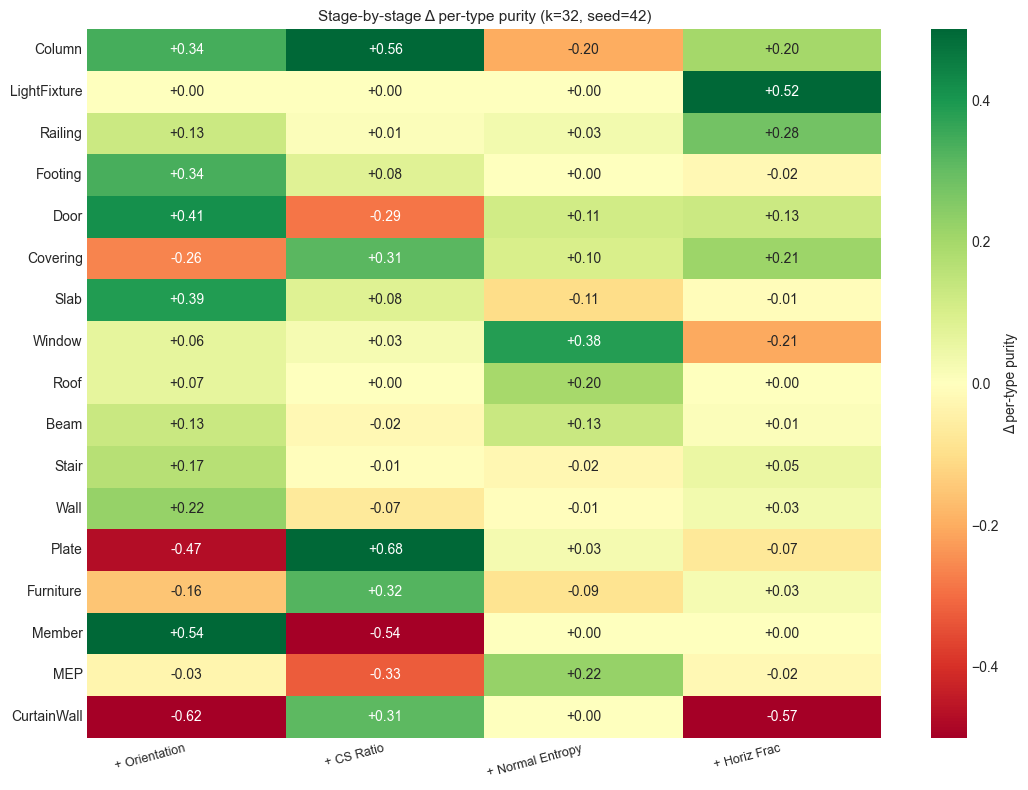

In [13]:
delta_table = journey.iloc[:, :-1].diff(axis=1).iloc[:, 1:]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(delta_table, annot=True, fmt='+.2f', cmap='RdYlGn', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, cbar_kws={'label': 'Δ per-type purity'})
ax.set_xticklabels([c.split('(')[0].strip() for c in delta_table.columns],
                   rotation=15, ha='right', fontsize=9)
ax.set_title(f'Stage-by-stage Δ per-type purity (k={K_MAIN}, seed=42)', fontsize=11)
plt.tight_layout(); plt.show()

## 5. Final state: full 9-feature clustering at k=32

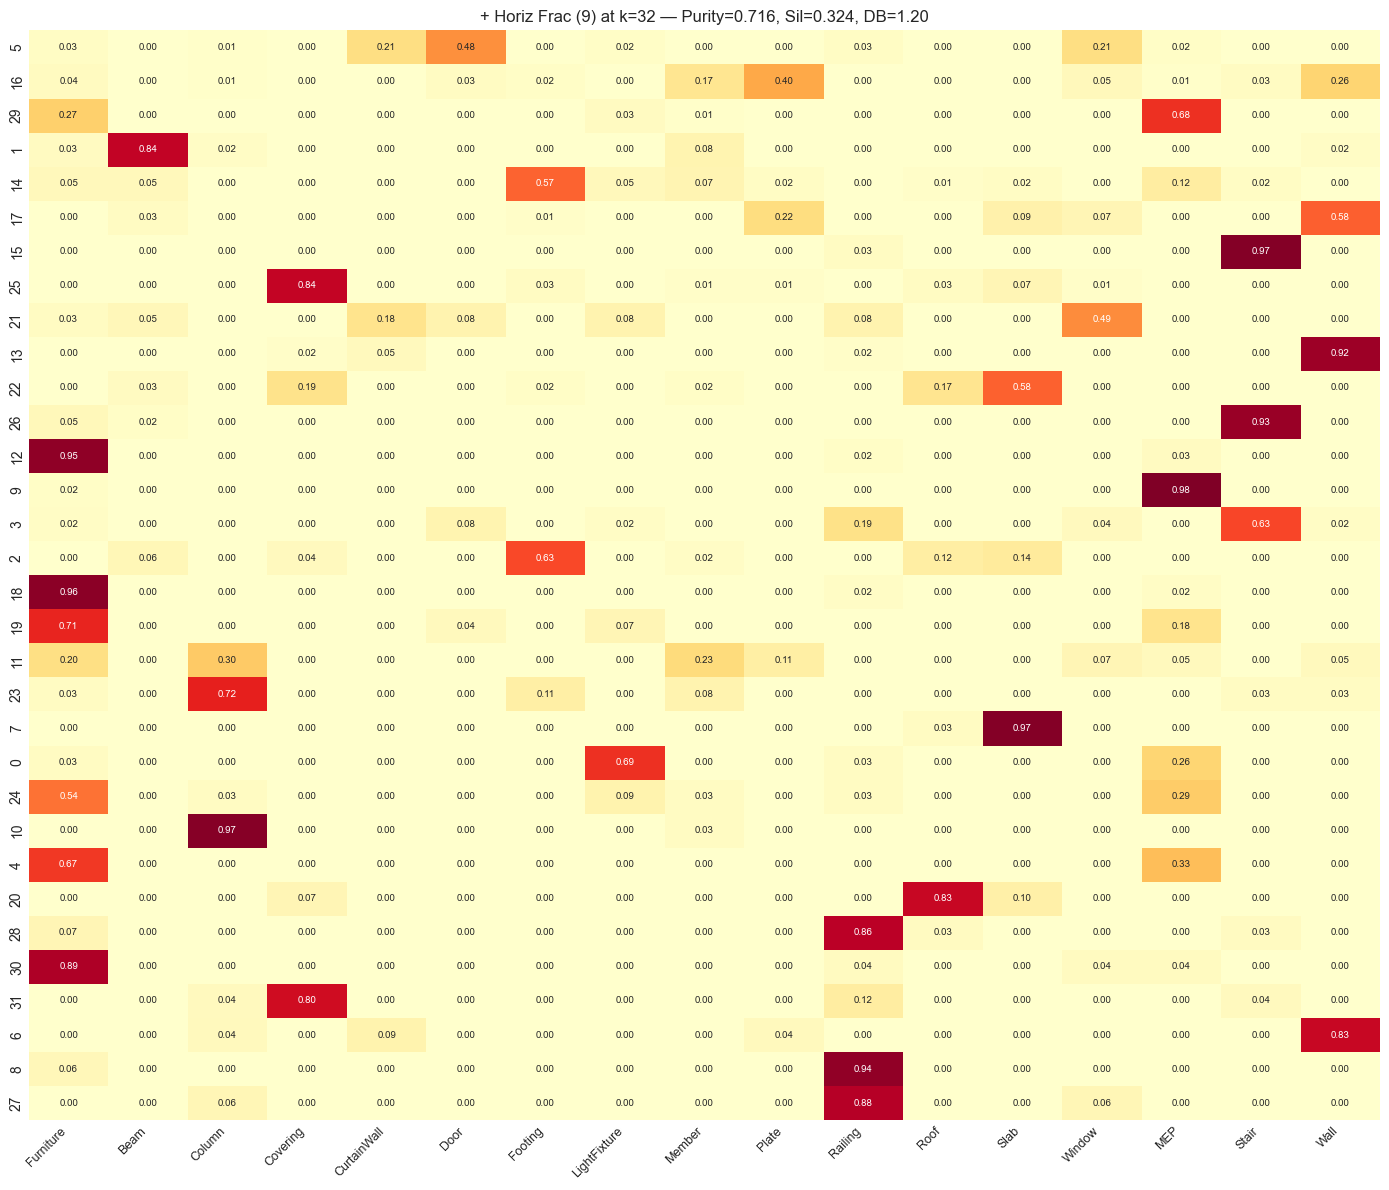

In [14]:
cols = cumulative_bounded_up_to('04_horiz_frac')
X = build_X(df, BASELINE, cols)
lab, Xs = kmeans_labels(X, K_MAIN, seed=42)
ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                 pd.Series(ifc_merged, name='Type'), normalize='index')
ct = ct.reindex(pd.Series(lab).value_counts().index)
ct.columns = [c.replace('Ifc', '') for c in ct.columns]

pur = compute_purity(lab, ifc_merged)
sil = silhouette_score(Xs, lab); db = davies_bouldin_score(Xs, lab)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            annot_kws={'size': 7}, cbar=False)
ax.set_title(f'+ Horiz Frac (9) at k={K_MAIN} — Purity={pur:.3f}, Sil={sil:.3f}, DB={db:.2f}', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

## 6. Data-driven takeaways

In [15]:
final = at_k['purity_mean'].iloc[-1]
base  = at_k['purity_mean'].iloc[0]
print(f'Purity climbs {base:.3f} → {final:.3f} at k={K_MAIN}  ({(final-base)/base:+.1%} relative)\n')

print('Per-stage ΔPurity (largest mover first):')
for name, d in deltas.sort_values(ascending=False).items():
    print(f'  {name:<25} {d:+.3f}')

print('\nTop 5 rescued types (Δpurity from baseline to final):')
for t, v in journey['Δtotal'].head(5).items():
    print(f'  {t:<20} {v:+.3f}')
print('\nTop 3 regressed types:')
for t, v in journey['Δtotal'].tail(3).items():
    print(f'  {t:<20} {v:+.3f}')

top_rf = final_imps.sort_values(ascending=False)
print('\nTop 5 RF-important features (final 9-feature model):')
for i, (f, v) in enumerate(top_rf.head(5).items(), 1):
    print(f'  {i}. {f:<20} {v:.3f}   (added in: {new_feat_tracker[f]})')

print(f'\nMax engineered |r|: {off_diag.max().max():.2f}')
print('Artifacts: results/feature_engineering/<stage>/  (pre_state_failure, separation_potential,')
print('           k_sweep_metrics, per_type_delta_k24/32, cluster_heatmap_k32, summary.md)')

Purity climbs 0.507 → 0.704 at k=32  (+38.9% relative)

Per-stage ΔPurity (largest mover first):
  Baseline (4, log)         +0.507
  + CS Ratio (7)            +0.079
  + Orientation (6)         +0.065
  + Normal Entropy (8)      +0.028
  + Horiz Frac (9)          +0.025

Top 5 rescued types (Δpurity from baseline to final):
  Column               +0.899
  LightFixture         +0.522
  Railing              +0.453
  Footing              +0.393
  Door                 +0.371

Top 3 regressed types:
  Member               +0.000
  MEP                  -0.157
  CurtainWall          -0.881

Top 5 RF-important features (final 9-feature model):
  1. horiz_frac           0.153   (added in: + Horiz Frac (9))
  2. log(CrossSectionArea) 0.135   (added in: Baseline (4, log))
  3. pc3_z                0.116   (added in: + Orientation (6))
  4. normal_entropy       0.110   (added in: + Normal Entropy (8))
  5. log(Volume)          0.106   (added in: Baseline (4, log))

Max engineered |r|: 0.67
Artifa